# 上证指数 ARIMA/SARIMA 时间序列预测

本作业以上证指数日度收盘价为对象，先完成价格序列的平稳性处理和 ARIMA/SARIMA 建模，再用样本外预测、残差检验和简单收益率回测评价模型效果。重点不是追求交易策略收益，而是完整展示时间序列建模流程。


## 环境与依赖

主要使用 `pandas`、`matplotlib`、`statsmodels` 和 `pmdarima`。其中 `statsmodels` 用于 ARIMA/SARIMA 拟合和残差检验，`pmdarima` 用于辅助选择模型阶数。


In [226]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning
import itertools
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pathlib import Path
from IPython.display import display
from plotnine import (
    ggplot, aes, geom_line, geom_point, geom_segment, geom_hline, geom_vline,
    geom_path, geom_ribbon, labs, theme, theme_bw, element_text, scale_color_manual,
    scale_linetype_manual, coord_equal, facet_wrap
)

# 固定项目目录，避免 Jupyter 启动目录不同导致相对路径失效。
PROJECT_DIR = Path(r"D:\python\projects\time-series")
if not PROJECT_DIR.exists():
    PROJECT_DIR = Path.cwd()

OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

warnings.filterwarnings("ignore")
        


## 数据读取


In [227]:
sz_index = pd.read_csv(r"D:\stata\多因子检验\上证指数合并后历史数据.csv")

In [228]:
sz_index.head()

,date,close_price,return
0,2000-01-10,"1,545.11",1.88%
1,2000-01-11,"1,479.78",-4.23%
2,2000-01-12,"1,438.02",-2.82%
3,2000-01-13,"1,424.44",-0.94%
4,2000-01-14,"1,408.85",-1.09%


## 数据预处理

保留日期和价格两列，将日期转为时间索引，并按日期排序。后续建模都基于这一条价格序列。


In [229]:
stock = sz_index[["date", "close_price"]].copy()
stock["date"] = pd.to_datetime(stock["date"], format="%Y-%m-%d", errors="coerce")

# Excel 中价格有时会被读成字符串，这里统一转成数值，避免后面画图时报 no numeric data。
stock["close_price"] = (
    stock["close_price"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)
stock["close_price"] = pd.to_numeric(stock["close_price"], errors="coerce")

stock = stock.dropna(subset=["date", "close_price"]).set_index("date").sort_index()
stock.index.name = "date"
stock.head()
        


,close_price
date,
2000-01-10,1545.11
2000-01-11,1479.78
2000-01-12,1438.02
2000-01-13,1424.44
2000-01-14,1408.85


## 划分训练集和测试集

这里把最后一个月留作样本外测试集，其余样本用于估计模型。时间序列不能随机打乱，否则会破坏先后顺序。


In [230]:
# 测试集取最后一个月，保持严格的时间先后顺序
cutoff = stock.index.max() - pd.DateOffset(months=1)

train = stock.loc[stock.index < cutoff]
test = stock.loc[stock.index >= cutoff]

print("Cutoff 日期:", cutoff)
print("训练集:", train.index.min(), "至", train.index.max(), "样本数:", len(train))
print("测试集:", test.index.min(), "至", test.index.max(), "样本数:", len(test))


Cutoff 日期: 2024-07-23 00:00:00
训练集: 2000-01-10 00:00:00 至 2024-07-22 00:00:00 样本数: 5947
测试集: 2024-07-23 00:00:00 至 2024-08-23 00:00:00 样本数: 24


## 绘图函数


In [231]:
def _to_numeric_series(x, name="value"):
    if isinstance(x, pd.DataFrame):
        x = x.select_dtypes(include="number").squeeze()
    else:
        x = x.squeeze()
    x = pd.to_numeric(x, errors="coerce").dropna()
    x.name = name
    return x


def _series_to_df(x, name="value"):
    s = _to_numeric_series(x, name=name)
    return pd.DataFrame({"date": s.index, name: s.values})


def plot_series(x, title):
    df = _series_to_df(x)
    p = (
        ggplot(df, aes("date", "value"))
        + geom_line(color="#1f77b4", size=0.8)
        + labs(title=title, x="Date", y="Value")
        + theme_bw()
        + theme(figure_size=(12, 6), axis_text_x=element_text(rotation=30, ha="right"))
    )
    display(p)
        


In [232]:
def plot_acf_pacf(x, title):
    s = _to_numeric_series(x)
    lag_count = min(20, max(1, len(s) // 2 - 1))

    acf_values = acf(s, nlags=lag_count, fft=False)
    pacf_values = pacf(s, nlags=lag_count, method="ywm")

    acf_df = pd.DataFrame({"lag": range(len(acf_values)), "value": acf_values, "type": "ACF"})
    pacf_df = pd.DataFrame({"lag": range(len(pacf_values)), "value": pacf_values, "type": "PACF"})
    corr_df = pd.concat([acf_df, pacf_df], ignore_index=True)

    p = (
        ggplot(corr_df, aes("lag", "value"))
        + geom_segment(aes(x="lag", xend="lag", yend="value"), y=0, color="#1f77b4")
        + geom_hline(yintercept=0, color="black", size=0.4)
        + geom_point(color="#1f77b4", size=1.6)
        + labs(title=title, x="Lag", y="Correlation")
        + theme_bw()
        + theme(figure_size=(12, 6), subplots_adjust={"hspace": 0.35})
        + facet_wrap("~type", ncol=1)
    )
    display(p)
        


## 序列平稳性观察

先观察原始价格、对数价格和一阶差分后的对数价格。价格序列通常带有明显趋势，直接建模容易违反平稳性假设，因此需要通过对数和差分处理。


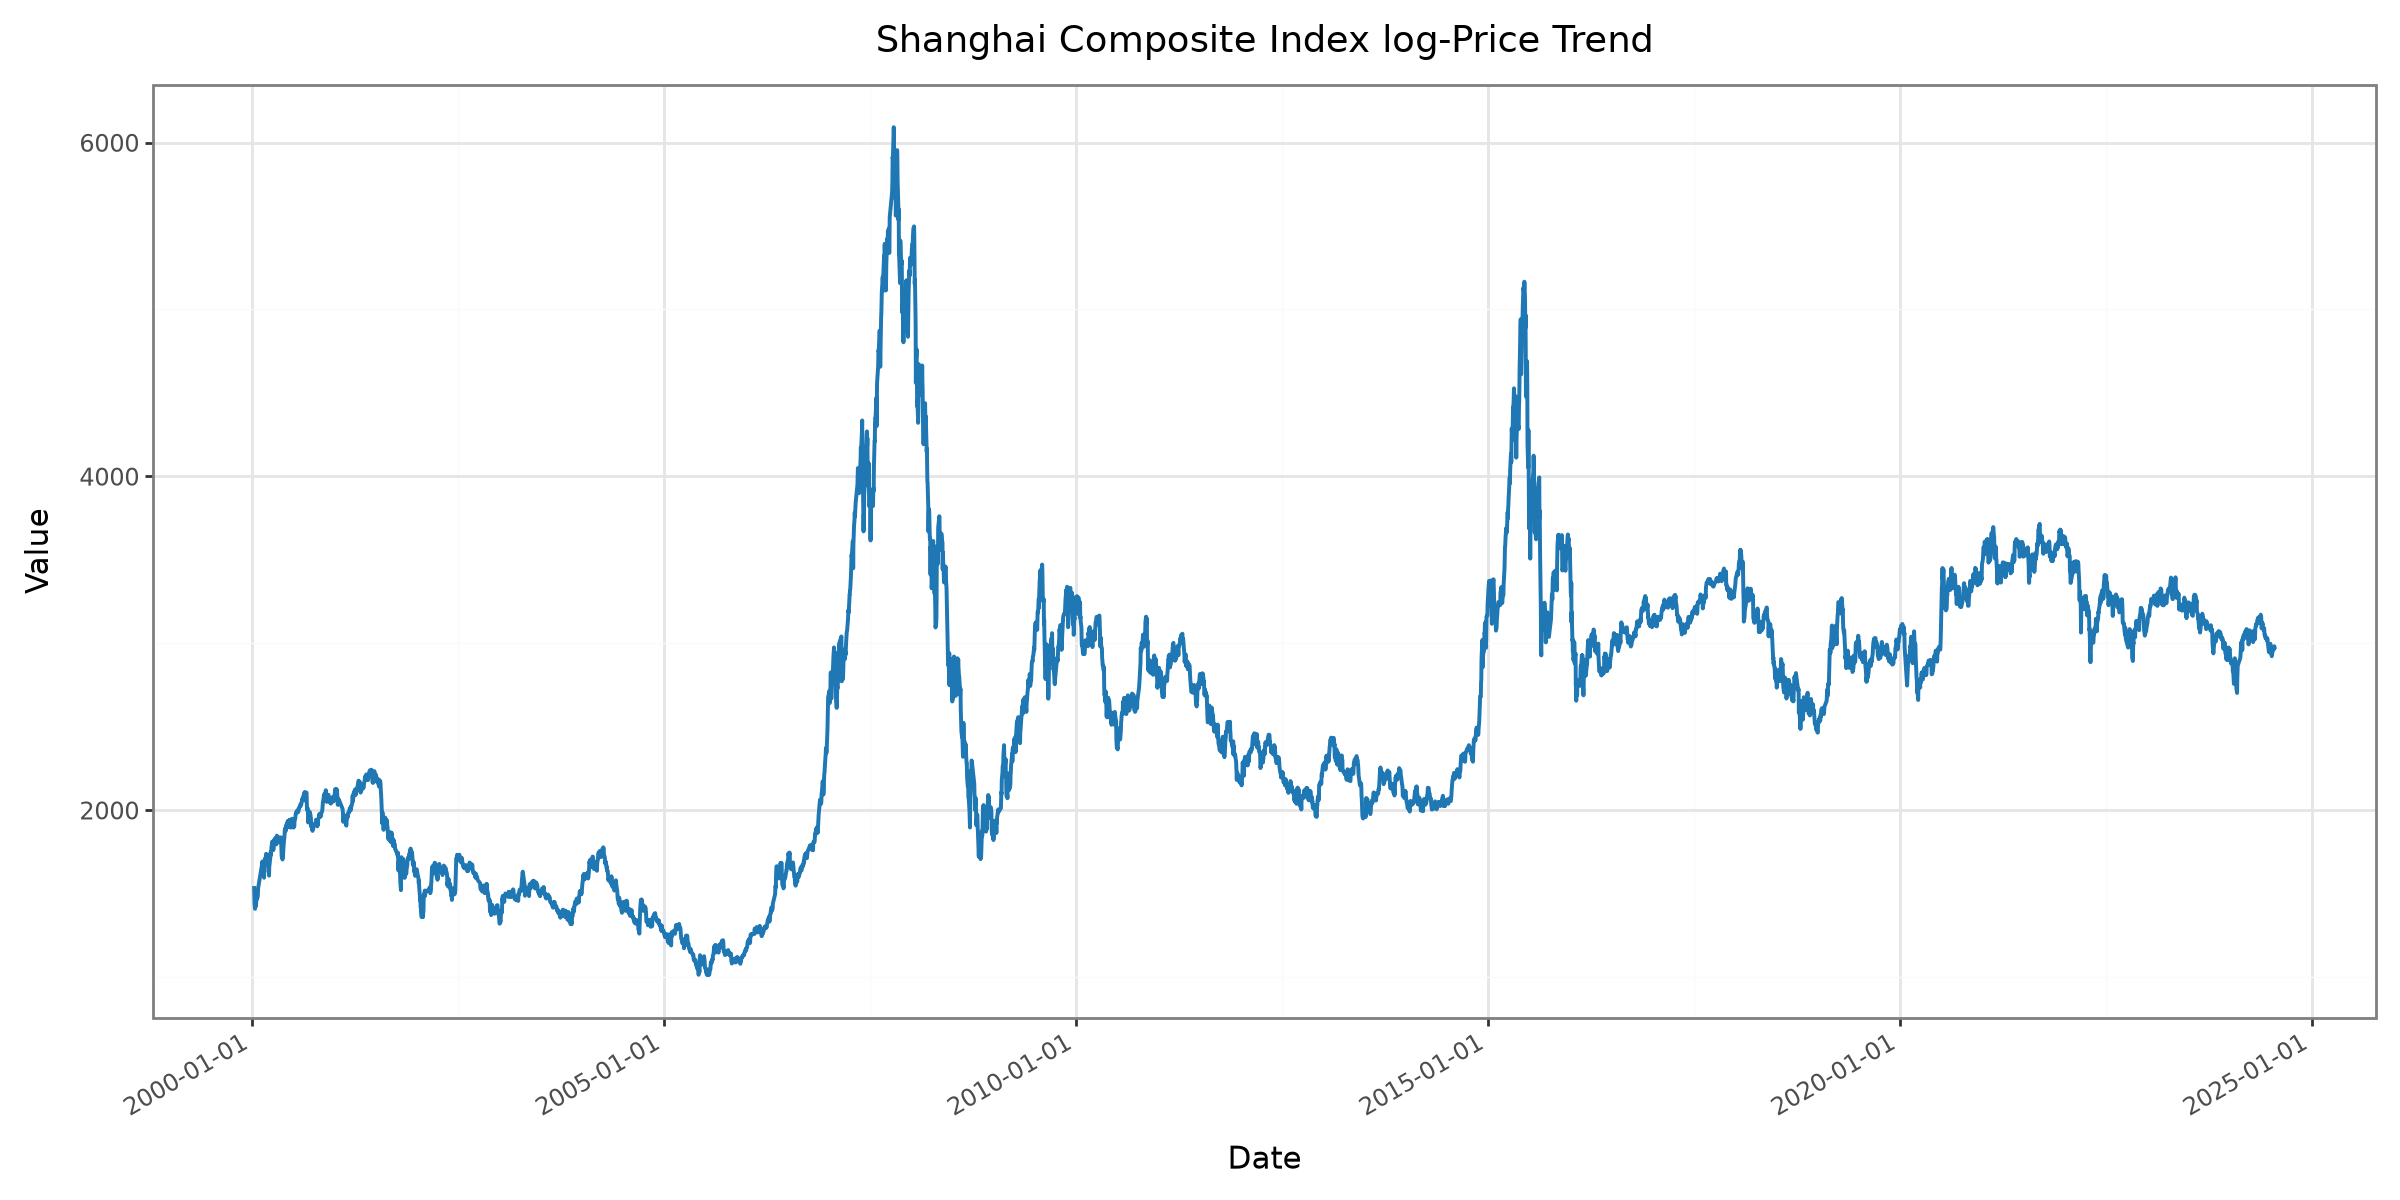

In [233]:
# 观察训练集的图形
plot_series(train,"Shanghai Composite Index log-Price Trend")

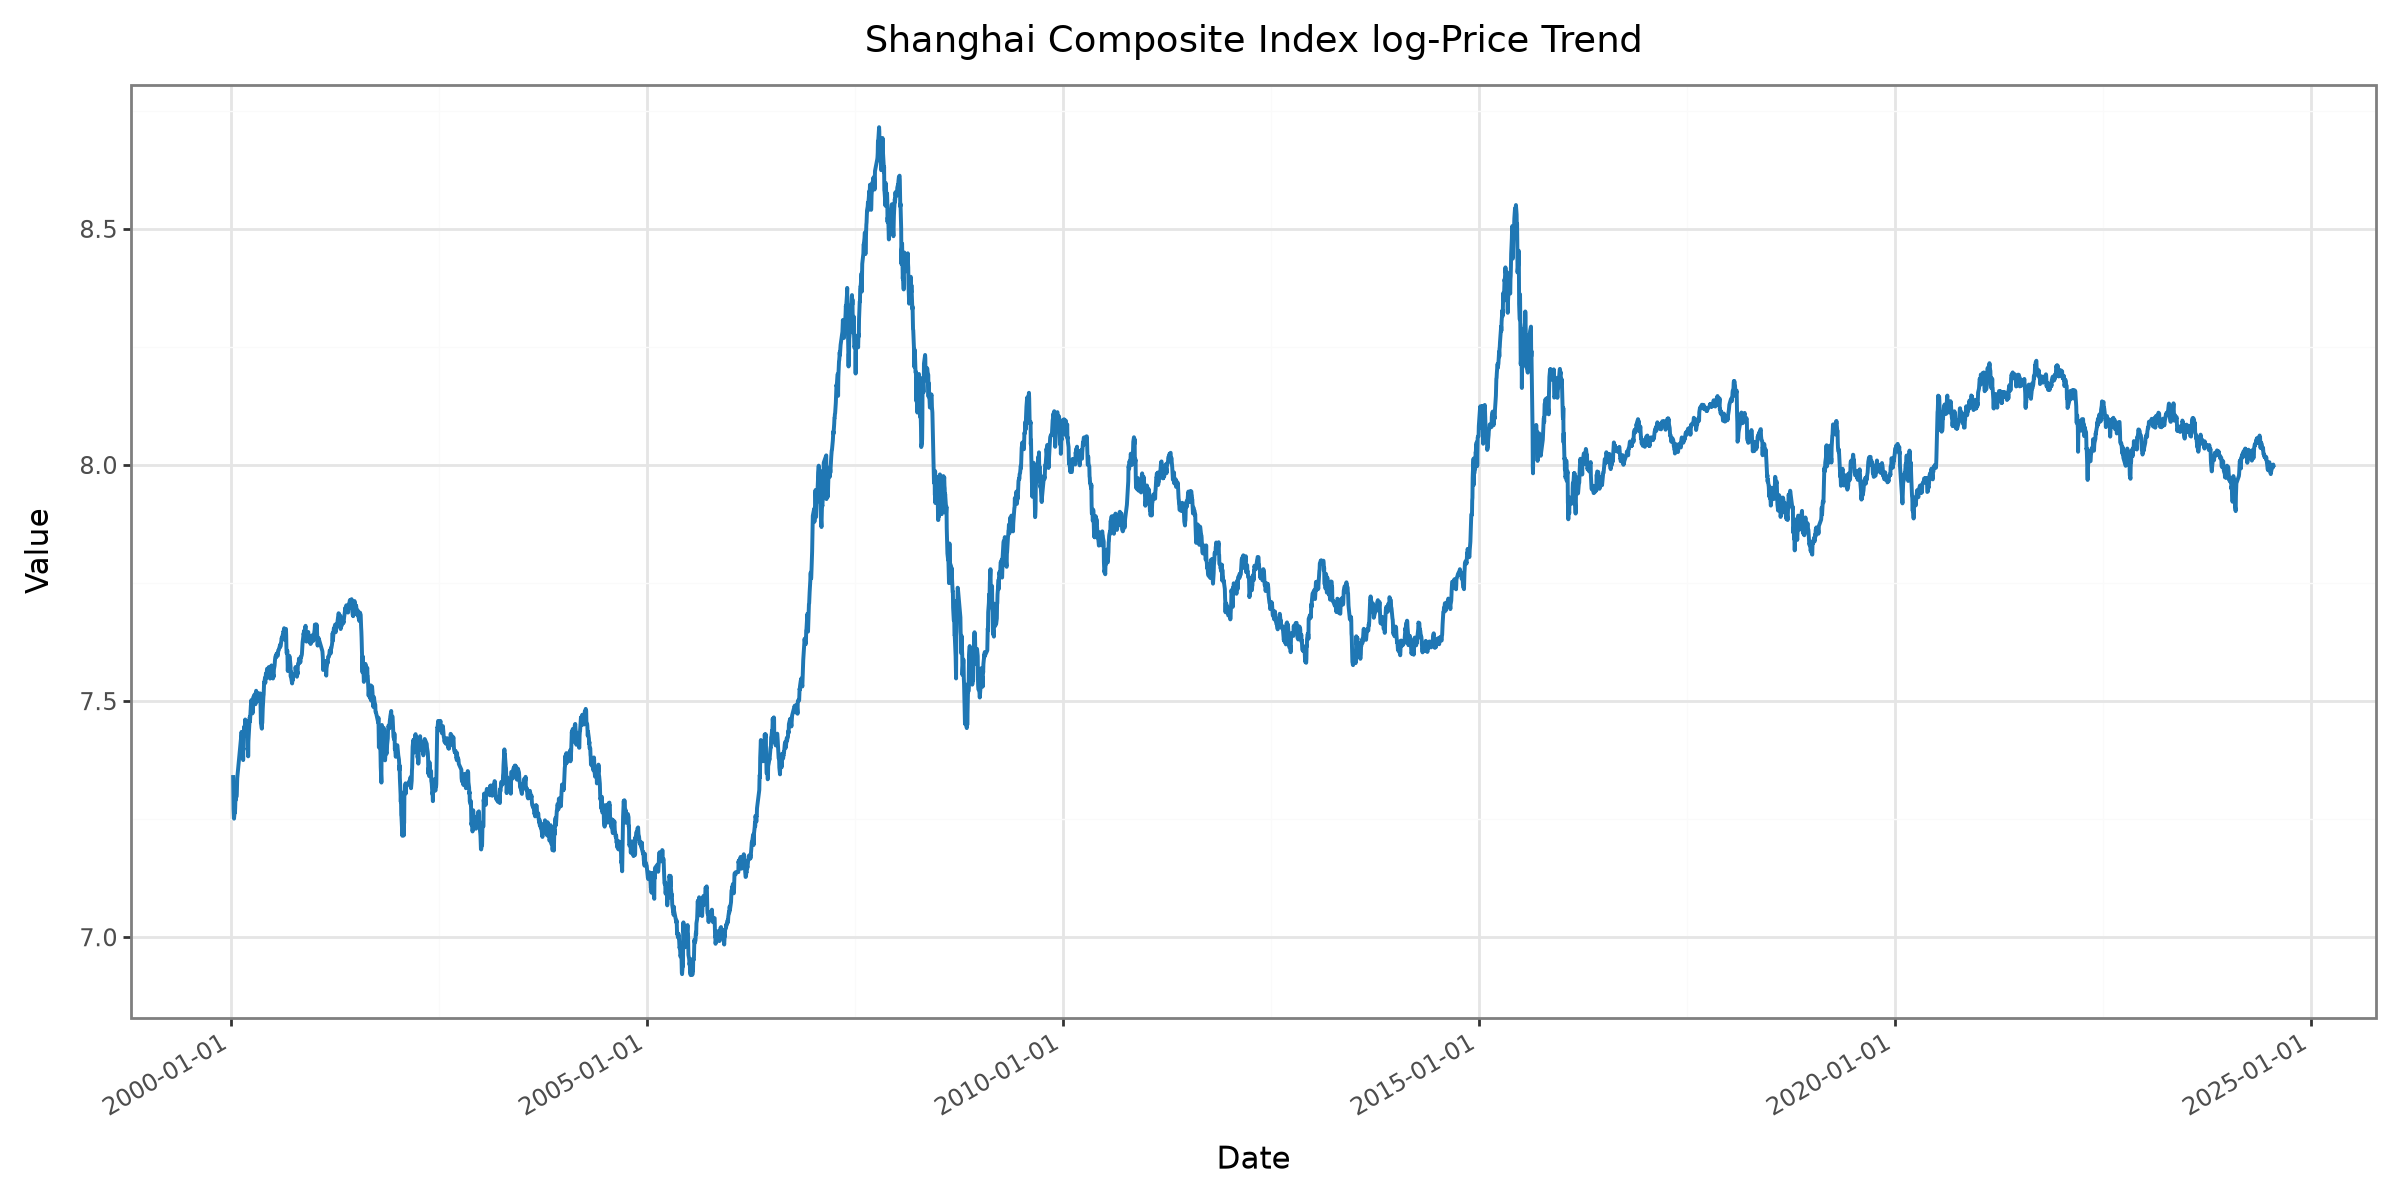

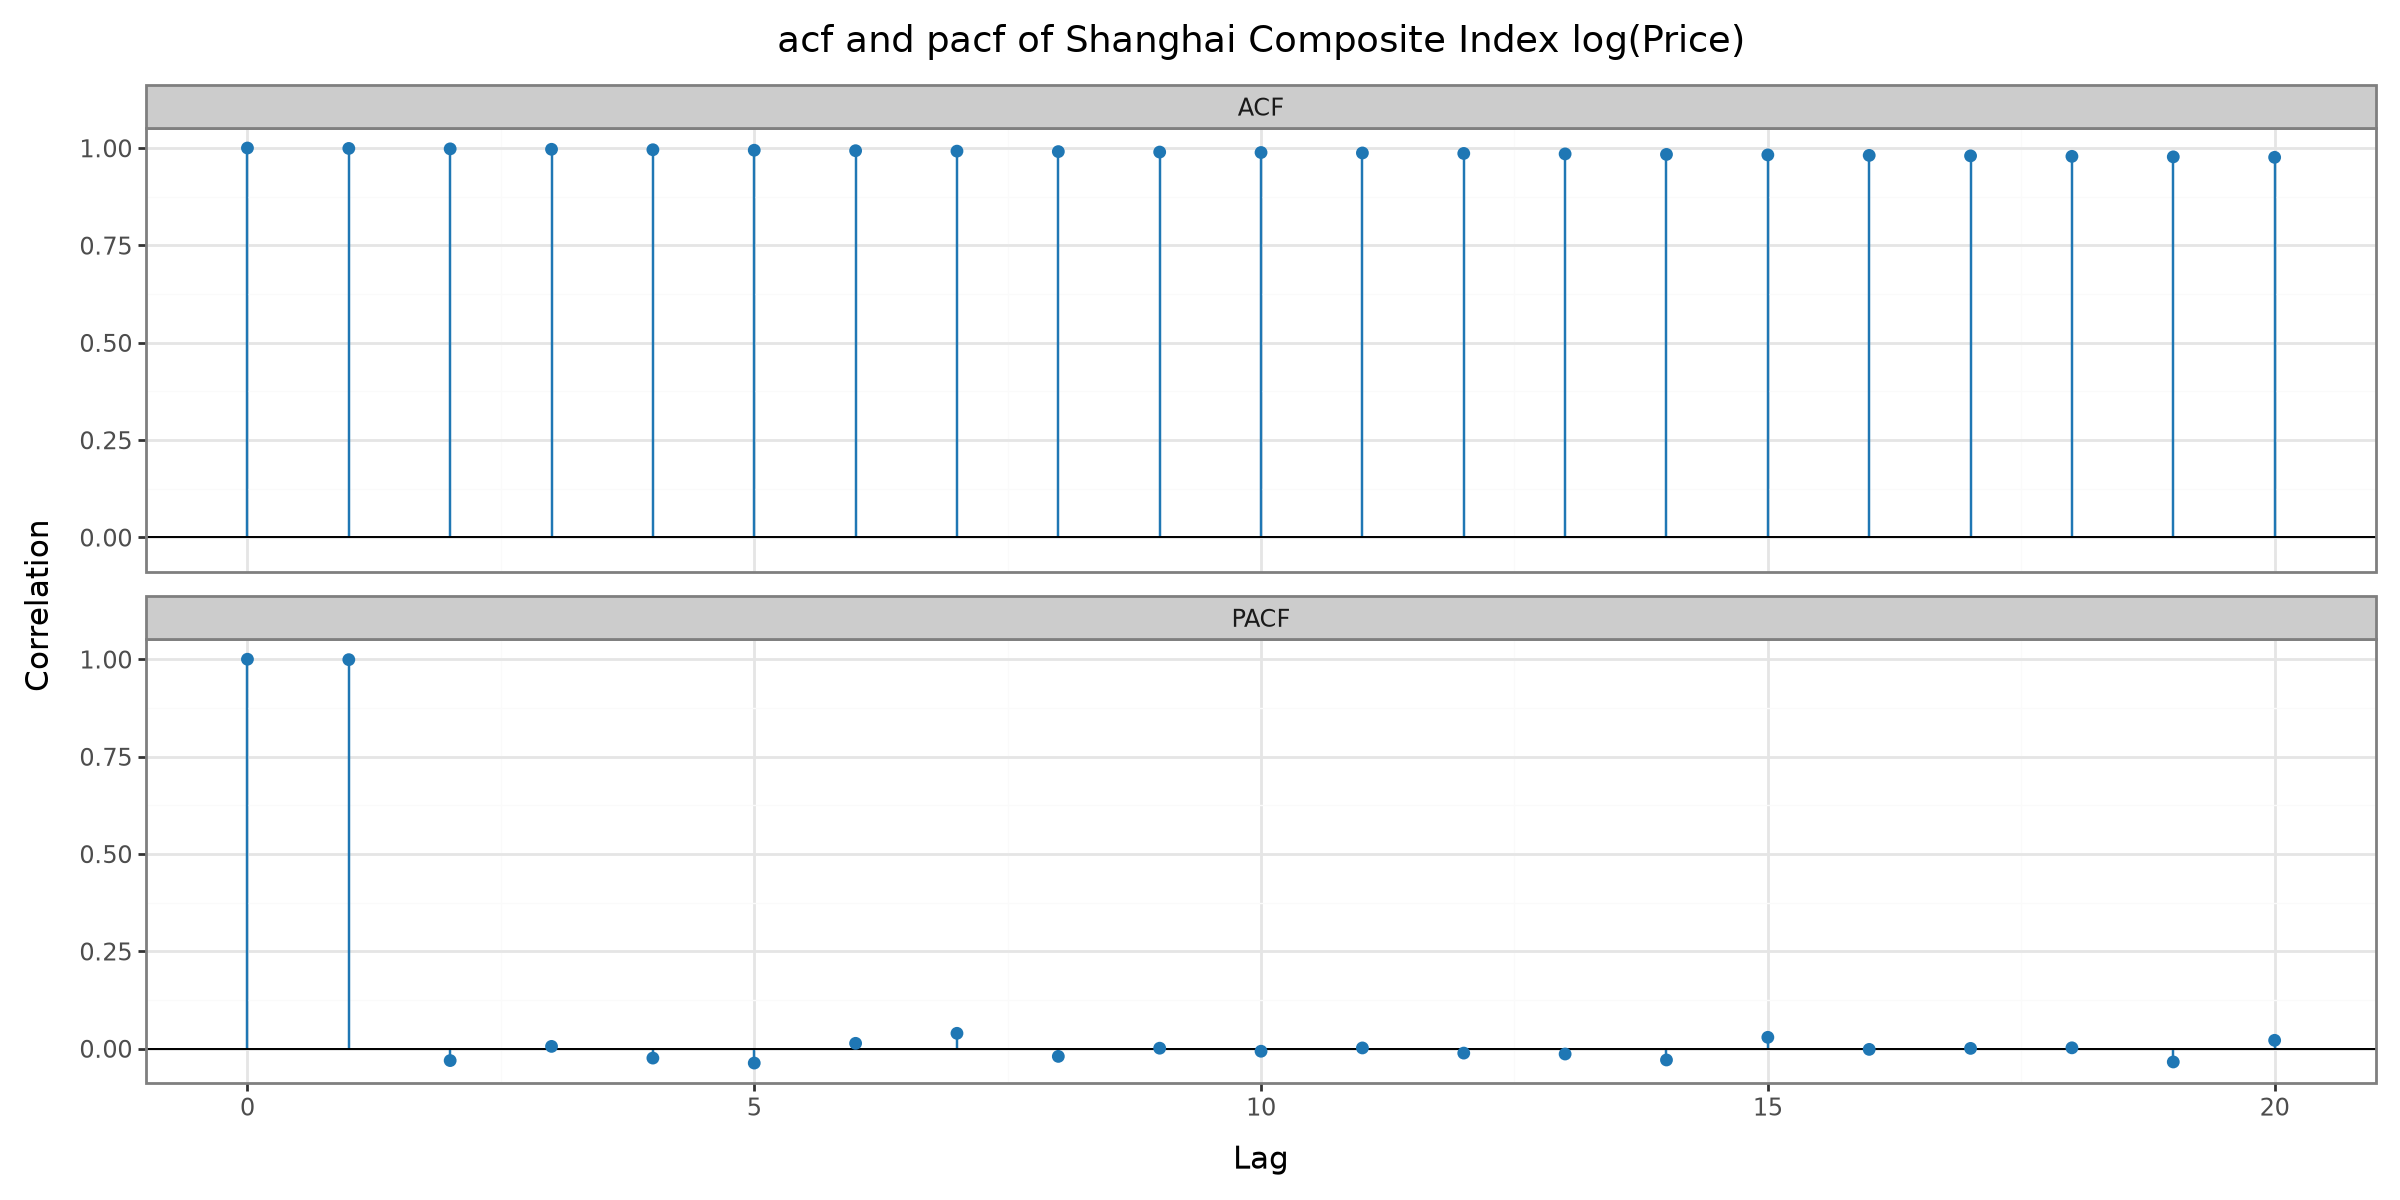

In [234]:
# 取对数以减少波动性
log_train = np.log(train)
log_test = np.log(test)

plot_series(log_train,"Shanghai Composite Index log-Price Trend")
plot_acf_pacf(log_train,"acf and pacf of Shanghai Composite Index log(Price)")

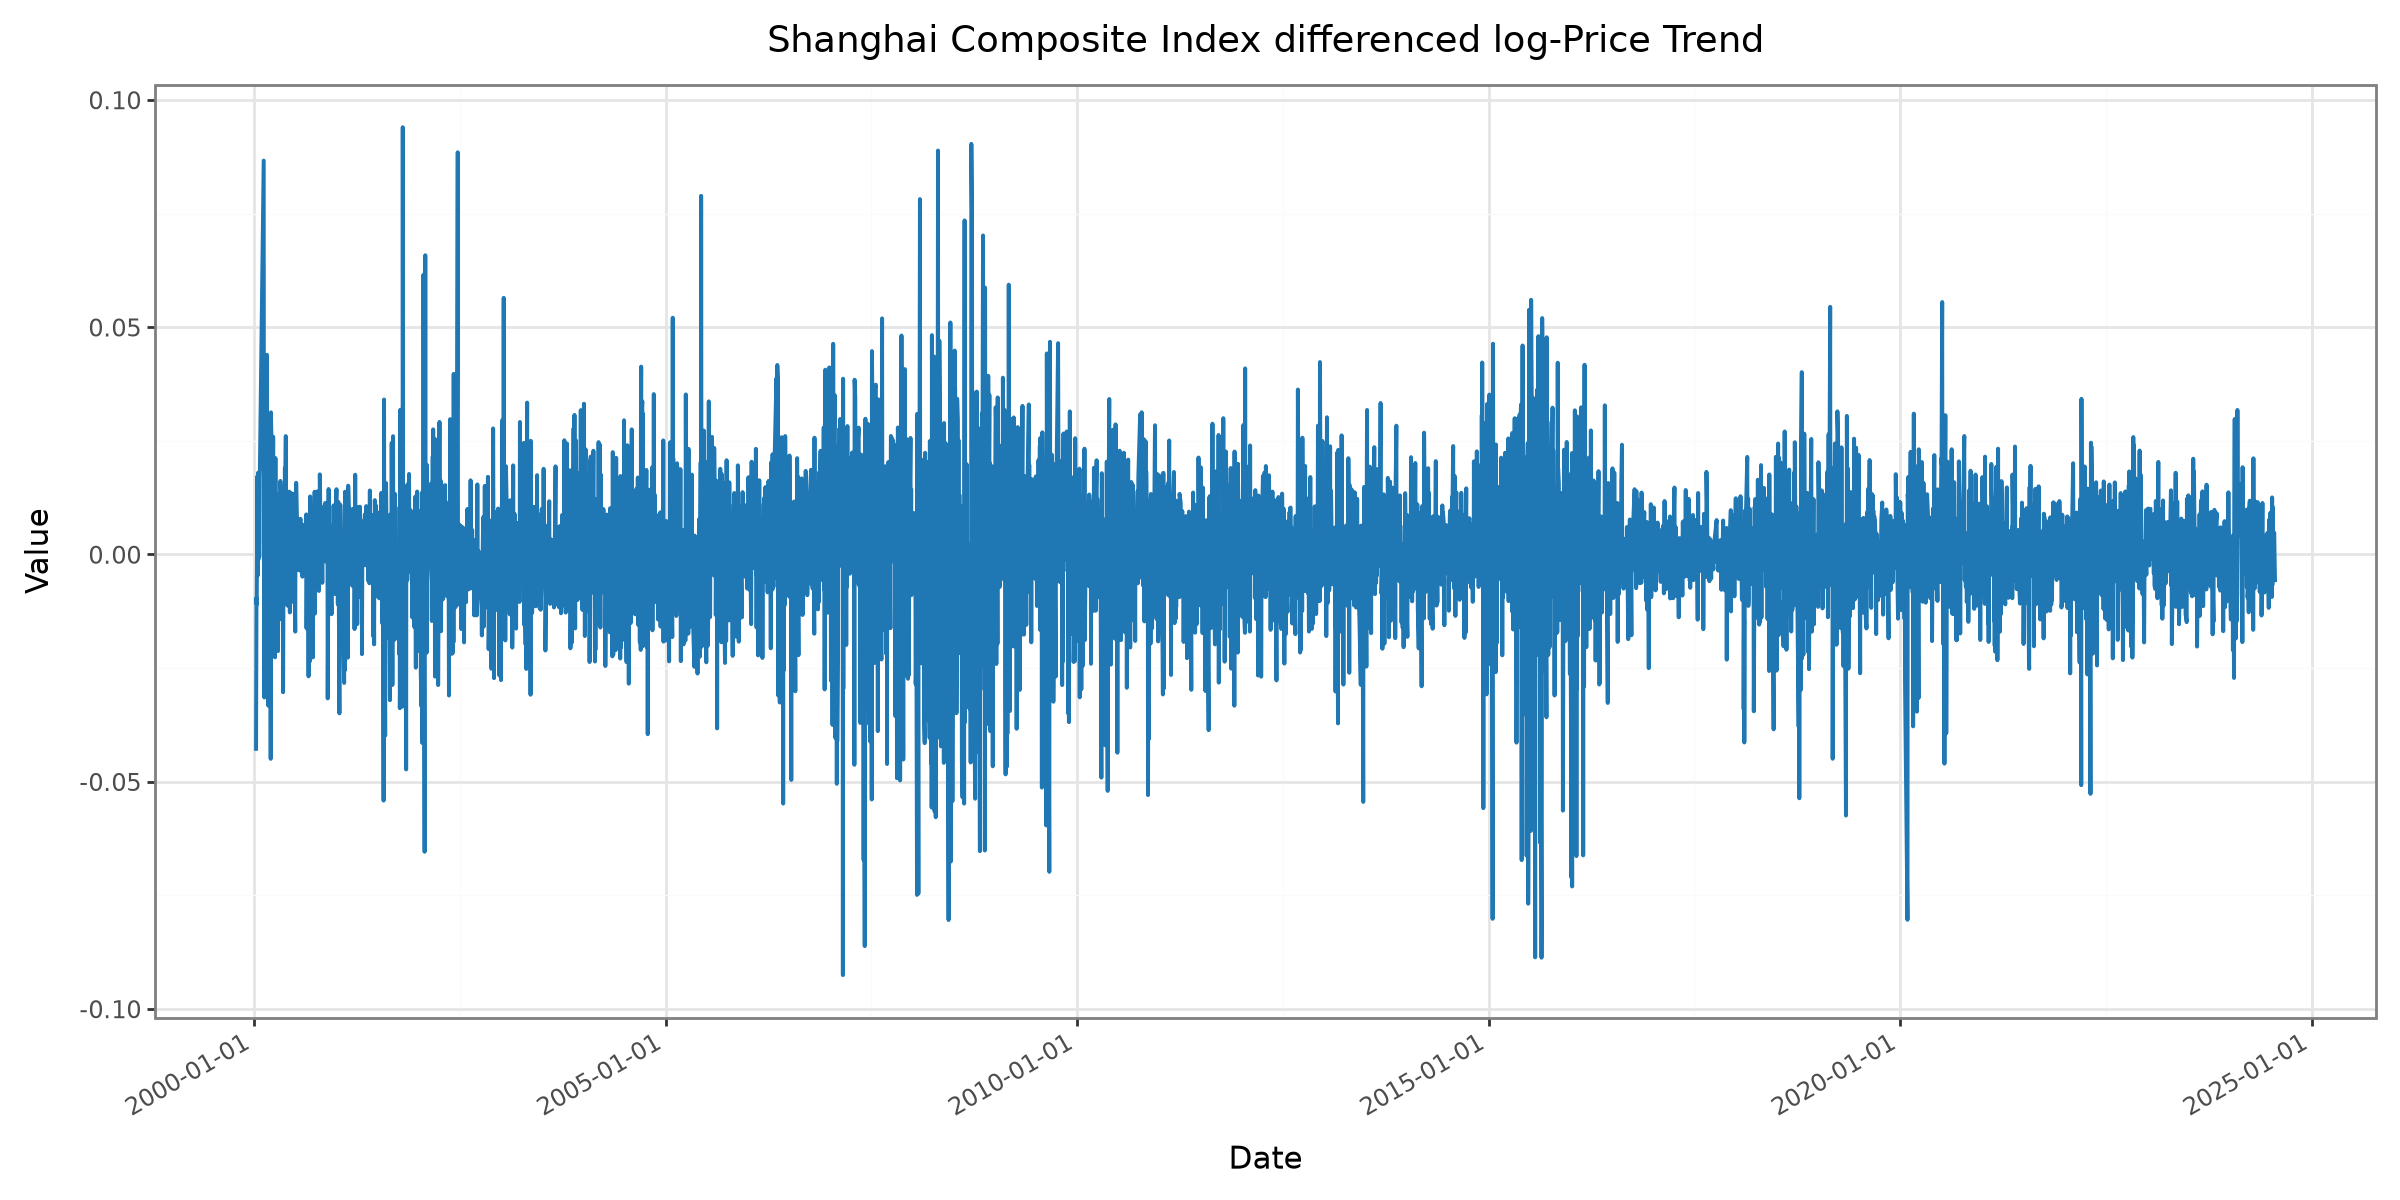

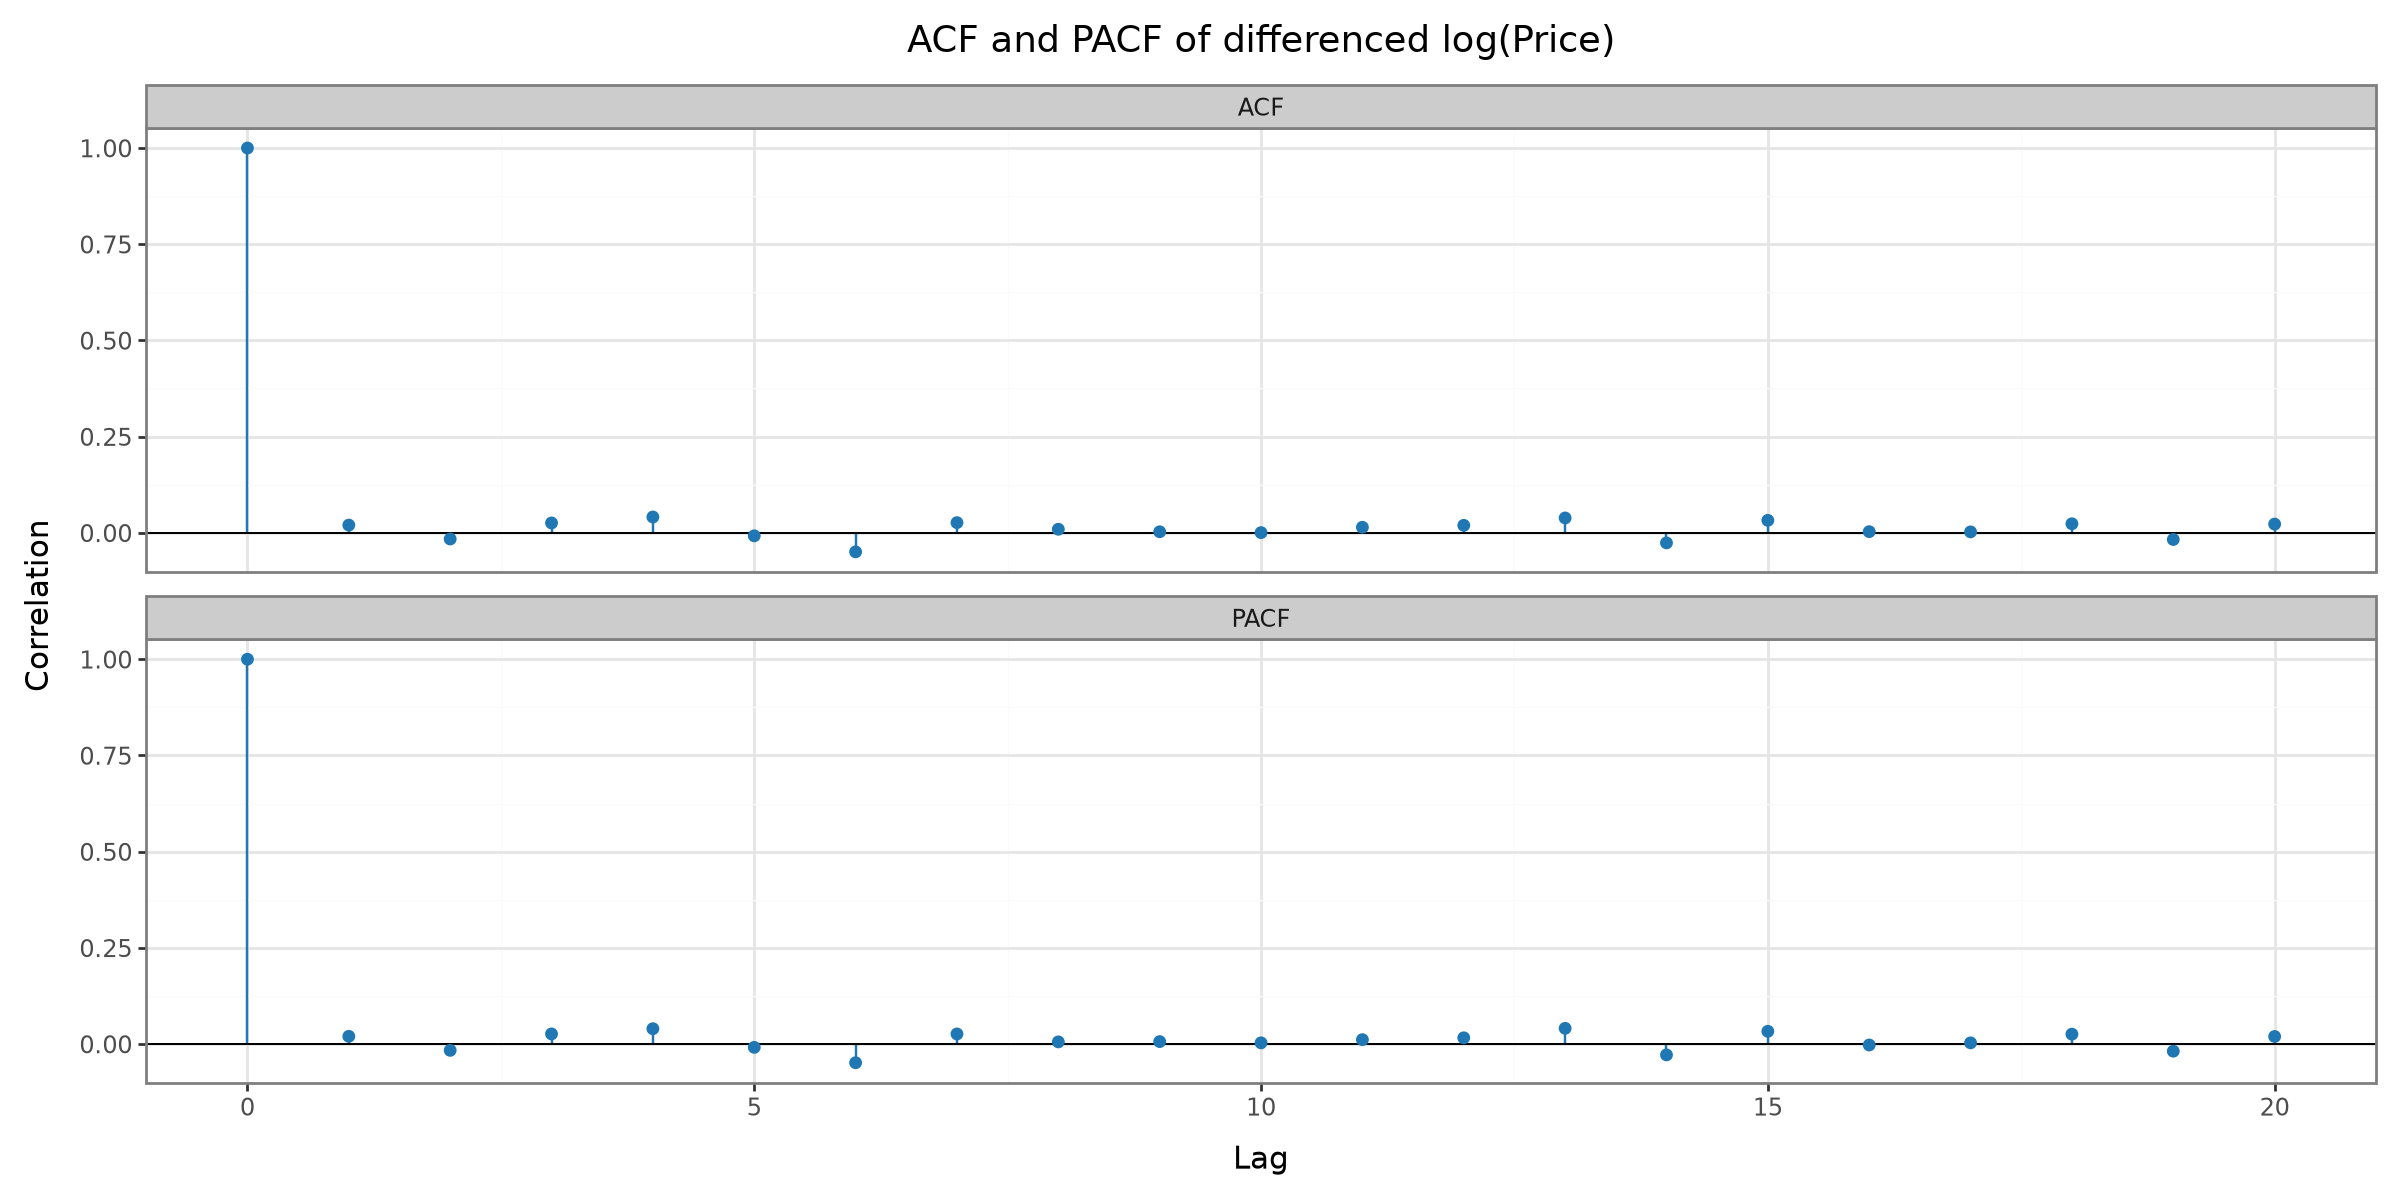

      lb_stat     lb_pvalue
1    2.353624  1.249921e-01
2    3.907848  1.417169e-01
3    7.768694  5.104200e-02
4   17.751406  1.380064e-03
5   18.127959  2.790238e-03
6   32.770134  1.160949e-05
7   36.889059  4.923163e-06
8   37.386347  9.770419e-06
9   37.425710  2.209040e-05
10  37.426465  4.774111e-05
11  38.651005  6.071453e-05
12  40.870554  5.150433e-05
13  49.695706  3.361976e-06
14  53.817951  1.380003e-06
15  60.039123  2.483324e-07
16  60.087611  5.058814e-07
17  60.117990  1.004812e-06
18  63.374882  5.763668e-07
19  65.193890  5.678257e-07
20  68.231113  3.532069e-07


In [235]:
# 对数价格一阶差分后，序列围绕 0 波动，平稳性明显改善
dlog_train = log_train.diff().dropna()
plot_series(dlog_train, "Shanghai Composite Index differenced log-Price Trend")
plot_acf_pacf(dlog_train, "ACF and PACF of differenced log(Price)")

print(acorr_ljungbox(dlog_train, lags=20, return_df=True))


**小结：** 原始价格和对数价格都表现出较强趋势，一阶差分后的对数价格波动更稳定。ACF/PACF 仍有短期相关性，因此后续使用 ARIMA 类模型刻画这部分结构。


## 模型阶数选择

分别使用 `auto_arima` 和网格搜索比较不同阶数的 AIC。AIC 越小表示在拟合效果和模型复杂度之间的折中更好。


In [236]:
# step3 选择最优的arma模型
#注意sm.tsa.arma_order_select_ic只能用 'n' 或 'c'，不支持趋势项和季节项。
#由于数据不平稳，所以不能调用sm.tsa.arma_order_select_ic筛选最优的p和q.
#两种方法：一是直接调用其他库，二是用“打擂法”程序进行格点搜索

#方法一：
import pmdarima as pm

model = pm.auto_arima(
    log_train,   # 如果是价格，通常先做差分/对数差分
    seasonal=False,   # 不考虑季节性
    d=1,           # 自动判断差分阶数
    max_p=5, max_q=5, # 最大 p,q 搜索范围
    information_criterion='aic', # 可以是 'aic' 或 'bic'
    stepwise=True,    # 启发式搜索，比全网格快
    suppress_warnings=True
)

# 输出最优阶数
print("最优阶数 (p,d,q):", model.order)

print(model.summary())

最优阶数 (p,d,q): (3, 1, 3)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 5947
Model:               SARIMAX(3, 1, 3)   Log Likelihood               16655.297
Date:                Sat, 15 Aug 2026   AIC                         -33296.593
Time:                        12:36:05   BIC                         -33249.760
Sample:                             0   HQIC                        -33280.322
                               - 5947                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4341      0.154      2.811      0.005       0.131       0.737
ar.L2         -0.7756      0.066    -11.721      0.000      -0.905      -0.646
ar.L3          0.2262      0

In [237]:
# 方法二：格点搜索的方法：基于arima进行搜索

def select_best_arima(series, p_max, d_max,q_max):
    """
    打擂法：寻找最优 ARIMA 模型 (p,d,q)

    参数:
        series: 时间序列 (pd.Series)
        p_max: p 的最大阶数
        d_max: d 的最大阶数
        q_max: q 的最大阶数

    返回:
        best_model: 最优模型
        best_param: (p,d,q)
        results_df: 所有结果的 DataFrame
    """
    parameters = itertools.product(range(p_max+1), range(d_max+1), range(q_max+1))

    #如果确定要做一次差分，即d=1,可以只设置两个参数
    #parameters = itertools.product(range(p_max+1),range(q_max+1))

    results = []
    best_aic = float("inf")
    best_model,best_param = None, None

    for param in parameters:
        try:
            model = ARIMA(series, order=param).fit()
                          
            #如果确定d =1 ,想减少搜索的次数，可以将d直接指定为1，此时代码如下
            # model = ARIMA(series, order=(param[0], 1, param[1])).fit()
        except Exception:
            continue

        aic = model.aic
        results.append([param, aic])

        # 打擂：更新最优
        if aic < best_aic:
            best_aic = aic
            best_model = model
            best_param = param

    results_df = pd.DataFrame(results, columns=["param", "aic"]).sort_values(by="aic")

    print("最优模型参数:", best_param, " AIC:", best_aic)
    return best_model, best_param, results_df


best_model1, best_param1, results_df1 = select_best_arima(log_train,p_max=5,d_max=1,q_max=5)

print(best_model1.summary())
print(results_df1.head())   # 显示最优的前几组参数

最优模型参数: (3, 1, 3)  AIC: -33296.59313251429
                               SARIMAX Results                                
Dep. Variable:            close_price   No. Observations:                 5947
Model:                 ARIMA(3, 1, 3)   Log Likelihood               16655.297
Date:                Sat, 15 Aug 2026   AIC                         -33296.593
Time:                        12:37:23   BIC                         -33249.760
Sample:                             0   HQIC                        -33280.322
                               - 5947                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4341      0.154      2.811      0.005       0.131       0.737
ar.L2         -0.7756      0.066    -11.721      0.000      -0.905      -0.646
ar.L3    

In [238]:
# 方法二：基于 SARIMAX 的网格搜索，seasonal_order 可用于控制季节项

def select_best_sarimax(series, p_max, d_max, q_max, seasonal_order):
    """
    网格搜索 SARIMAX(p,d,q)(P,D,Q,m)，以 AIC 作为筛选标准。
    """
    parameters = itertools.product(range(p_max + 1), range(d_max + 1), range(q_max + 1))

    results = []
    best_aic = float("inf")
    best_model, best_param = None, None

    for param in parameters:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", ValueWarning)
                warnings.simplefilter("ignore", ConvergenceWarning)
                model_fit = SARIMAX(
                    series,
                    order=param,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                ).fit(disp=False)
        except Exception:
            continue

        aic = model_fit.aic
        results.append([param[0], param[1], param[2], aic])

        if aic < best_aic:
            best_aic = aic
            best_model = model_fit
            best_param = param

    results_df = pd.DataFrame(results, columns=["p", "d", "q", "aic"]).sort_values(by="aic")
    print("最优模型参数:", best_param, " AIC:", best_aic)
    return best_model, best_param, results_df


# 无季节项 SARIMAX 搜索，用作 ARIMA 结果的对照
best_model2, best_param2, results_df2 = select_best_sarimax(
    log_train, p_max=5, d_max=1, q_max=5, seasonal_order=(0, 0, 0, 0)
)

print(best_model2.summary())
print(results_df2.head())


最优模型参数: (3, 1, 2)  AIC: -33286.22298094117
                               SARIMAX Results                                
Dep. Variable:            close_price   No. Observations:                 5947
Model:               SARIMAX(3, 1, 2)   Log Likelihood               16649.111
Date:                Sat, 15 Aug 2026   AIC                         -33286.223
Time:                        12:38:14   BIC                         -33246.083
Sample:                             0   HQIC                        -33272.277
                               - 5947                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2912      0.069      4.213      0.000       0.156       0.427
ar.L2         -0.7257      0.065    -11.154      0.000      -0.853      -0.598
ar.L3    

**小结：** 从 AIC 看，不同搜索方法给出的最优阶数略有差异。这说明样本很长时，AIC 对细小拟合差异比较敏感，所以后面还需要结合残差检验和样本外预测判断模型是否可用。


## 模型稳定性与残差检验

阶数确定后，检查 AR/MA 特征根以及残差自相关。如果残差仍然存在明显自相关，说明模型还没有充分提取序列中的信息。


In [239]:
# step4 进行平稳性和可逆性检验
def plot_roots_simple(poly, title):
    """
    画 AR/MA 滞后多项式的根。
    poly: list/np.array，多项式系数。
    """
    roots = np.roots(poly)

    circle = pd.DataFrame({
        "x": np.cos(np.linspace(0, 2 * np.pi, 300)),
        "y": np.sin(np.linspace(0, 2 * np.pi, 300)),
    })
    roots_df = pd.DataFrame({"real": roots.real, "imag": roots.imag})

    p = (
        ggplot()
        + geom_path(circle, aes("x", "y"), color="#1f77b4", linetype="dashed", size=0.8)
        + geom_hline(yintercept=0, color="black", size=0.3)
        + geom_vline(xintercept=0, color="black", size=0.3)
        + geom_point(roots_df, aes("real", "imag"), color="#d62728", size=2.5)
        + coord_equal()
        + labs(title=title, x="Real part", y="Imag part")
        + theme_bw()
        + theme(figure_size=(6, 6))
    )
    display(p)

    print("Roots:", roots)
    print("Modulus:", np.abs(roots))
        


In [240]:
# auto_arima 选择的模型阶数为 (5, 1, 0)，因此这里只需要检查 AR 根
phi = model.params().filter(like="ar.")
theta = model.params().filter(like="ma.")

print("AR params:", phi)
print("MA params:", theta)


AR params: ar.L1    0.434133
ar.L2   -0.775554
ar.L3    0.226175
dtype: float64
MA params: ma.L1   -0.412438
ma.L2    0.746333
ma.L3   -0.168534
dtype: float64


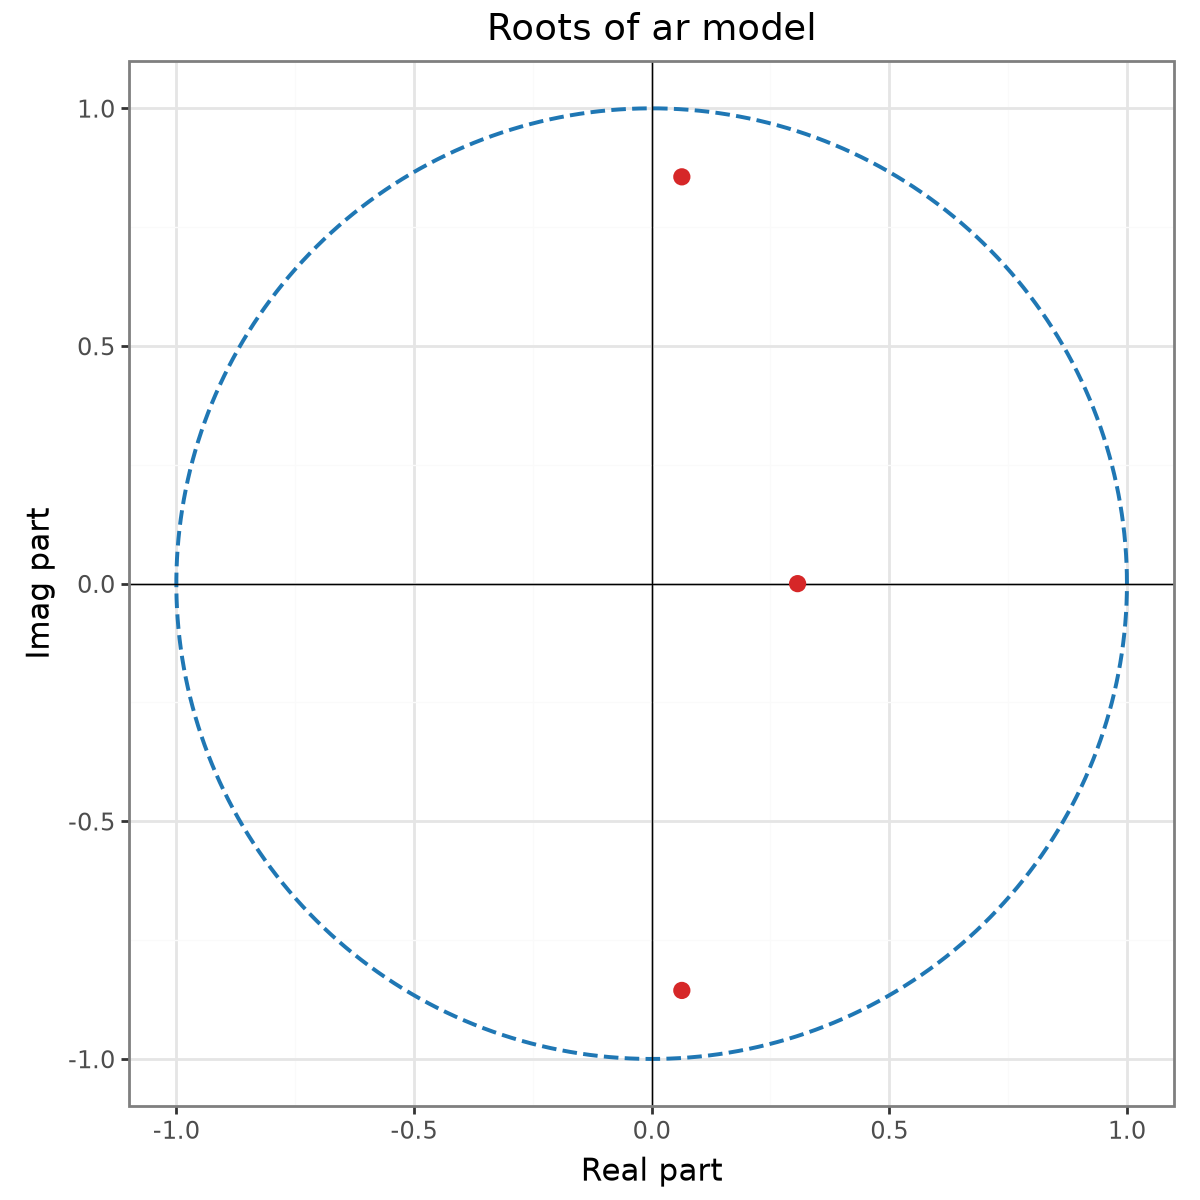

Roots: [0.0635271 +0.85586376j 0.0635271 -0.85586376j 0.30707847+0.j        ]
Modulus: [0.85821819 0.85821819 0.30707847]


In [241]:
ar_poly = np.r_[1, -phi]       # [1, -phi1, -phi2, ...]
#ma_poly = np.r_[1,  theta]     # [1,  theta1, theta2, ...]
plot_roots_simple(ar_poly, "Roots of ar model")
#plot_roots_simple(ma_poly, "Roots of ma model")

In [242]:
# 获得残差，并进行独立性检验
resid = model.resid()
lb = acorr_ljungbox(resid, lags=[4, 20], return_df=True, model_df=2)
print(lb)

     lb_stat  lb_pvalue
4   0.297603    0.86174
20  1.535939    1.00000


In [243]:
# 也可以看看基于arima选取的最优模型（p,d,q):(1,1,5)
params = best_model1.params  
print(params)

phi = params.filter(like='ar.')
theta = params.filter(like='ma.')

print("AR 系数:", phi.values)
print("MA 系数:", theta.values)

ar.L1     0.434133
ar.L2    -0.775554
ar.L3     0.226175
ma.L1    -0.412438
ma.L2     0.746333
ma.L3    -0.168534
sigma2    0.000216
dtype: float64
AR 系数: [ 0.43413268 -0.77555408  0.22617511]
MA 系数: [-0.41243768  0.74633322 -0.1685343 ]


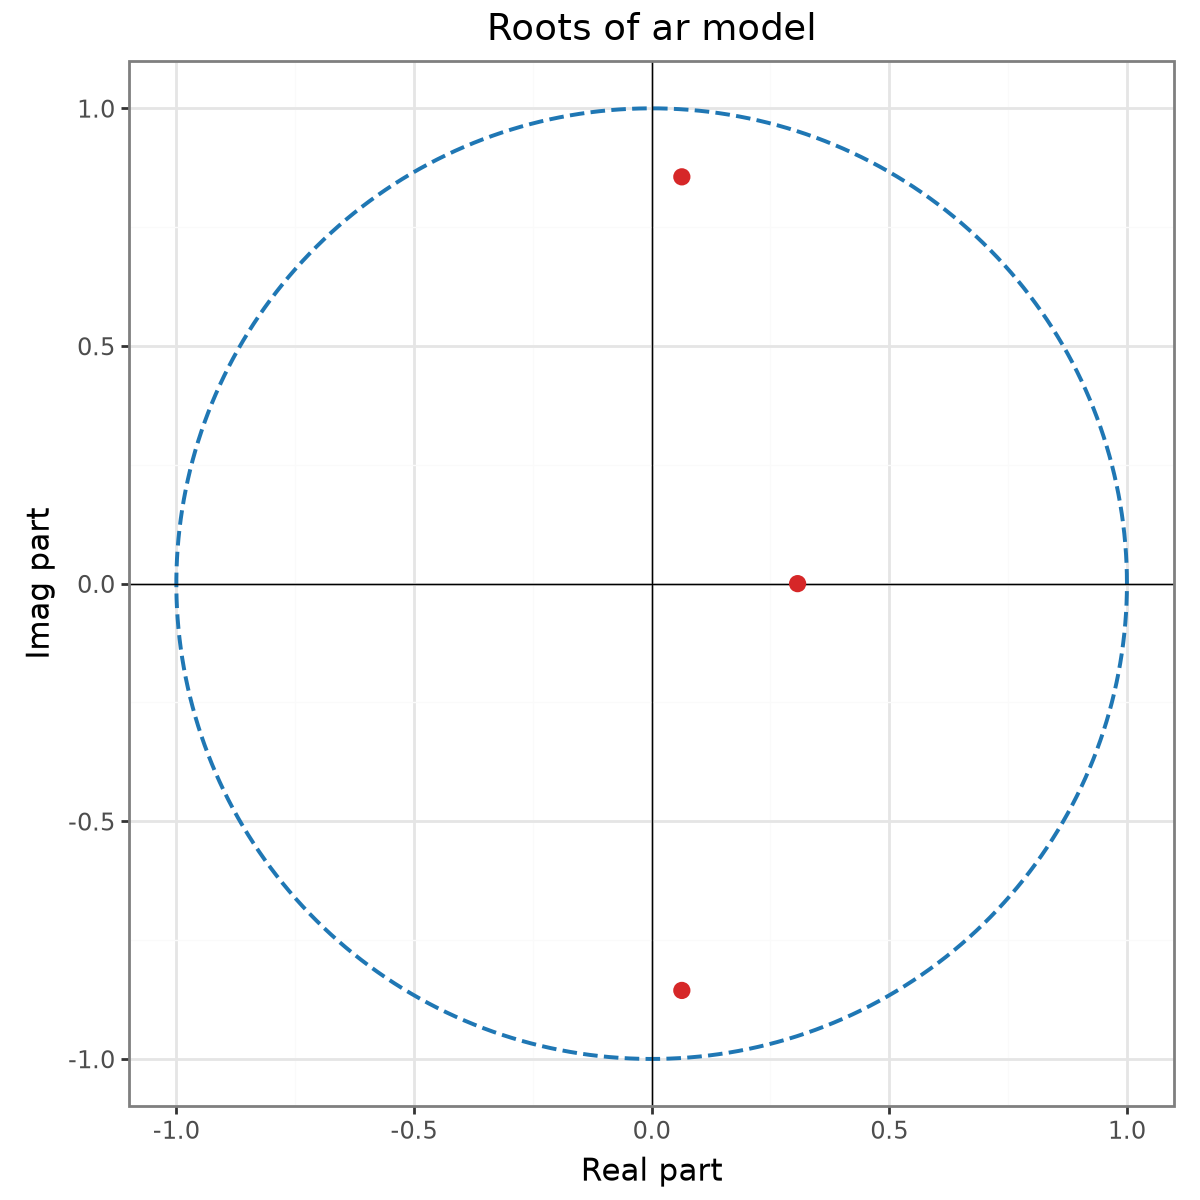

Roots: [0.0635271 +0.85586376j 0.0635271 -0.85586376j 0.30707847+0.j        ]
Modulus: [0.85821819 0.85821819 0.30707847]


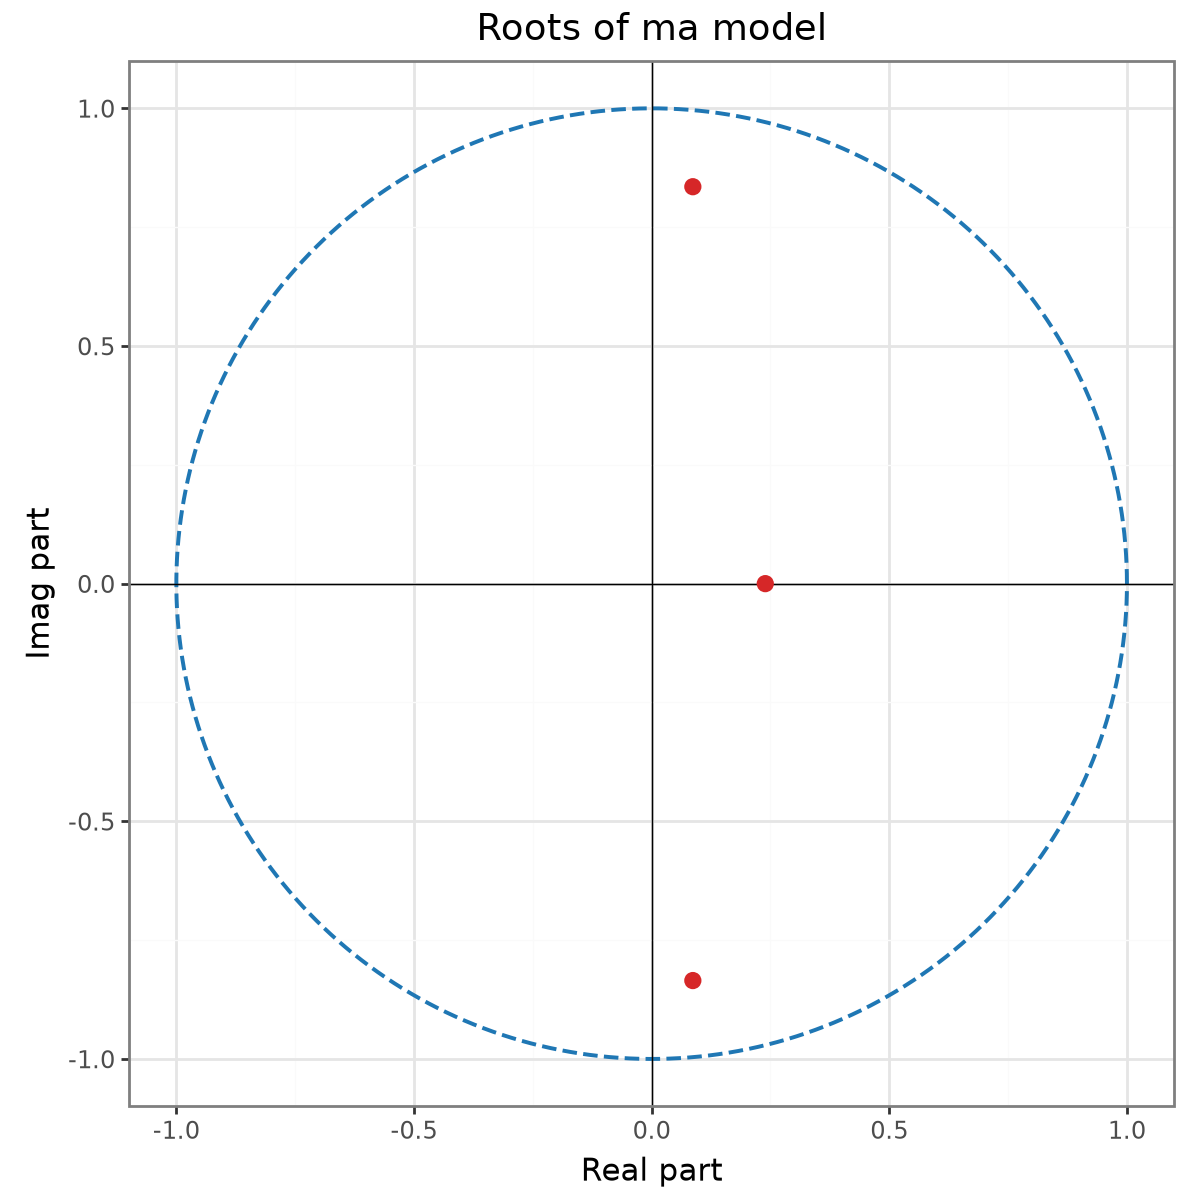

Roots: [0.08667193+0.83509026j 0.08667193-0.83509026j 0.23909381+0.j        ]
Modulus: [0.83957595 0.83957595 0.23909381]


In [244]:
ar_poly = np.r_[1, -phi]       # [1, -phi1, -phi2, ...]
ma_poly = np.r_[1,  theta]     # [1,  theta1, theta2, ...]
plot_roots_simple(ar_poly, "Roots of ar model")
plot_roots_simple(ma_poly, "Roots of ma model")

In [245]:
# 获得残差，并进行独立性检验
resid = best_model1.resid
lb = acorr_ljungbox(resid, lags=[4, 20], return_df=True, model_df=2)
print(lb)

     lb_stat  lb_pvalue
4   0.297603    0.86174
20  1.535939    1.00000


**小结：** Ljung-Box 检验用于判断残差是否仍有自相关。如果 p 值较小，说明残差并非完全白噪声，模型对短期波动的解释仍有限；这也是金融价格序列建模中比较常见的情况。


## 样本外预测与误差评估

使用训练集拟合出的模型预测测试集，并将 log 空间的预测值还原为价格。误差指标主要使用 MAE 和 RMSE。


In [246]:
# step5 基于arma(5,1,0)进行预测：包括训练集真实值、训练集拟合值（样本内预测值）、测试集真实值、测试集预测值 + 区间

# 1）先观察下样本内拟合值，看有没有缺失值
fitted_log = model.predict_in_sample()  # log 空间
fitted_log.head()

date
2000-01-10    0.000000
2000-01-11    7.342850
2000-01-12    7.298722
2000-01-13    7.271380
2000-01-14    7.260561
Name: predicted_mean, dtype: float64

In [247]:
# 修正第一个预测值：由于 d=1 差分，首个预测值需要替换为真实值
fitted_log.iloc[0] = log_train.iloc[0]
fitted_log.head()

date
2000-01-10    7.342850
2000-01-11    7.342850
2000-01-12    7.298722
2000-01-13    7.271380
2000-01-14    7.260561
Name: predicted_mean, dtype: float64

In [248]:
# 还原到价格空间，并对齐训练集索引
fitted = pd.Series(np.exp(fitted_log), index=train.index[-len(fitted_log):])
fitted.head()

date
2000-01-10    1545.110000
2000-01-11    1545.110000
2000-01-12    1478.409056
2000-01-13    1438.534392
2000-01-14    1423.054785
Name: predicted_mean, dtype: float64

In [249]:
# 2）样本外预测（Out-of-sample forecast）
n_periods = len(log_test)   # 测试集步数
forecast_log, conf_int_log = model.predict(n_periods=n_periods, return_conf_int=True)

# 转换为 Series，并还原到价格空间
forecast = pd.Series(np.exp(np.asarray(forecast_log)), index=test.index)
conf_df = pd.DataFrame(np.exp(conf_int_log), index=test.index, columns=["Lower", "Upper"])

print(forecast)
print(conf_df)

date
2024-07-23    2963.870844
2024-07-24    2965.246258
2024-07-25    2964.927137
2024-07-26    2963.643952
2024-07-29    2963.645364
2024-07-30    2964.568943
2024-07-31    2964.678616
2024-08-01    2964.010200
2024-08-02    2963.843901
2024-08-05    2964.314848
2024-08-06    2964.497137
2024-08-07    2964.173378
2024-08-08    2963.997993
2024-08-09    2964.214150
2024-08-12    2964.370802
2024-08-13    2964.231487
2024-08-14    2964.098411
2024-08-15    2964.184109
2024-08-16    2964.293015
2024-08-19    2964.243730
2024-08-20    2964.157256
2024-08-21    2964.182568
2024-08-22    2964.249476
2024-08-23    2964.239333
dtype: float64
                  Lower        Upper
date                                
2024-07-23  2879.724907  3050.475537
2024-07-24  2845.630333  3089.890233
2024-07-25  2819.536339  3117.815084
2024-07-26  2795.414209  3141.997864
2024-07-29  2774.234679  3165.988050
2024-07-30  2756.734606  3188.072221
2024-07-31  2740.891522  3206.737379
2024-08-01  2725.293754

In [250]:
# 3）合并结果 & 误差度量
pred_df = pd.DataFrame({
    "Actual": test.iloc[:, 0],
    "Forecast": forecast,
    "Lower": conf_df["Lower"],
    "Upper": conf_df["Upper"]
}, index=test.index)
print(pred_df)

              Actual     Forecast        Lower        Upper
date                                                       
2024-07-23  2915.369  2963.870844  2879.724907  3050.475537
2024-07-24  2901.952  2965.246258  2845.630333  3089.890233
2024-07-25  2886.742  2964.927137  2819.536339  3117.815084
2024-07-26  2890.897  2963.643952  2795.414209  3141.997864
2024-07-29  2891.845  2963.645364  2774.234679  3165.988050
2024-07-30  2879.300  2964.568943  2756.734606  3188.072221
2024-07-31  2938.749  2964.678616  2740.891522  3206.737379
2024-08-01  2932.387  2964.010200  2725.293754  3223.636518
2024-08-02  2905.338  2963.843901  2710.628279  3240.713873
2024-08-05  2860.698  2964.314848  2697.516921  3257.500425
2024-08-06  2867.284  2964.497137  2685.242310  3272.793386
2024-08-07  2869.834  2964.173378  2673.108418  3286.931333
2024-08-08  2869.901  2963.997993  2661.405177  3300.994594
2024-08-09  2862.194  2964.214150  2650.524848  3315.028543
2024-08-12  2858.205  2964.370802  2640.

In [251]:
# 4)计算误差指标
mae  = (pred_df["Actual"] - pred_df["Forecast"]).abs().mean()
rmse = np.sqrt(((pred_df["Actual"] - pred_df["Forecast"])**2).mean())
print("MAE:", mae, " RMSE:", rmse)

MAE: 83.9892045384791  RMSE: 87.38234225081737


**小结：** MAE 和 RMSE 衡量的是指数点位误差。由于指数本身有趋势，价格预测图通常看起来较平滑，但这不等于模型具备稳定的交易价值，因此后面进一步检查收益率预测。


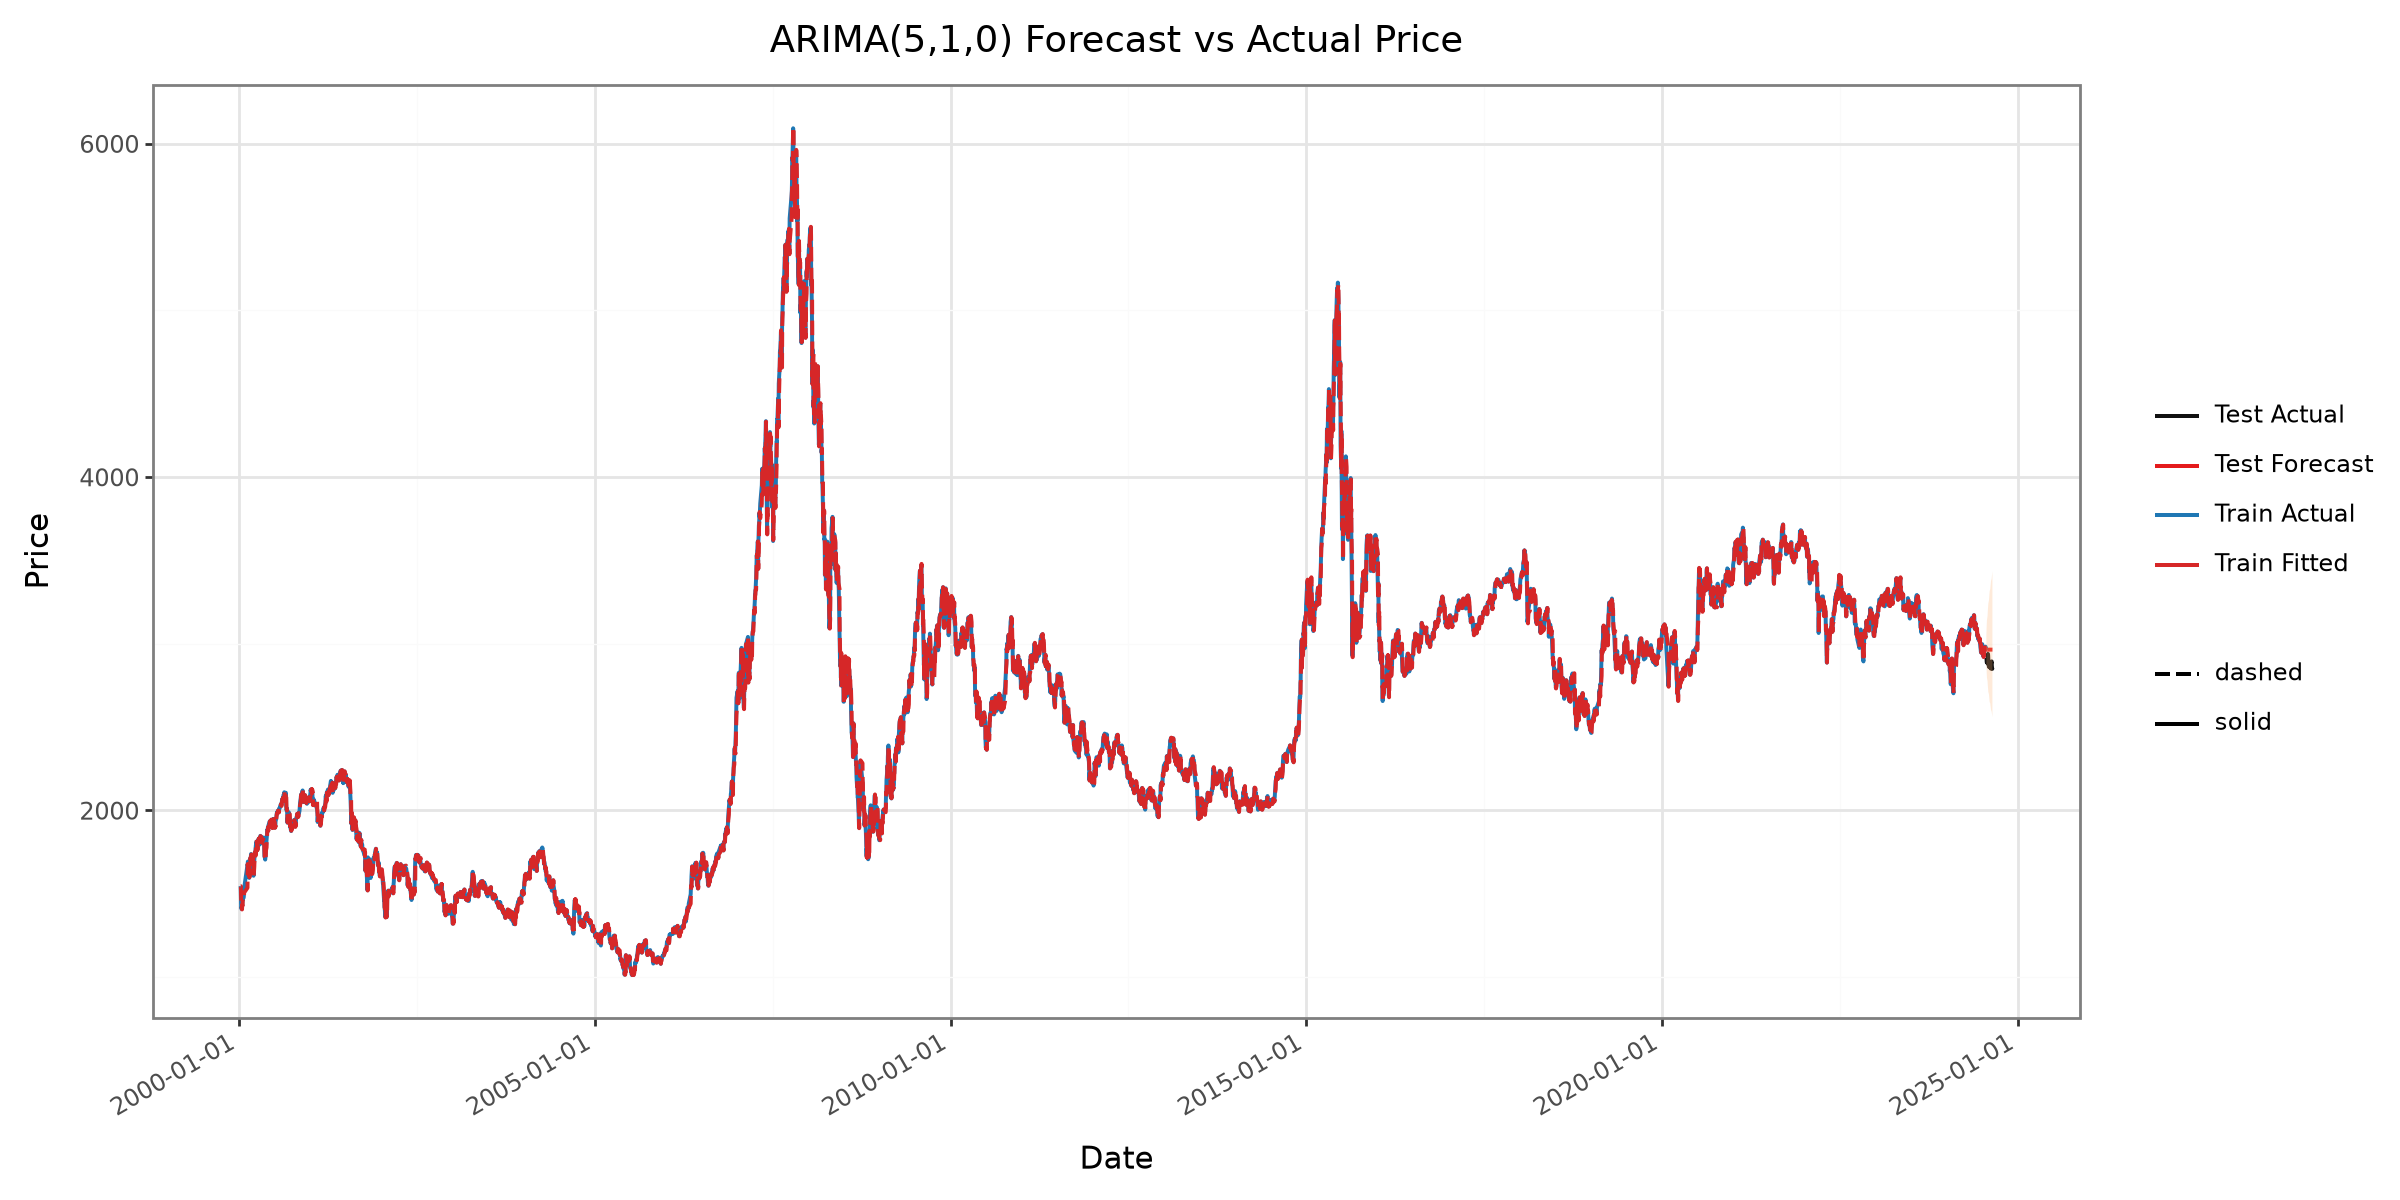

In [252]:
def _pick_col(df, names, pos):
    if isinstance(names, str):
        names = [names]
    for name in names:
        if name in df.columns:
            return df[name]
    return df.iloc[:, pos]


def plot_forecast_result(in_sample_df, pred_df, title, focus_start=None, show_train=True, show_interval=True):
    train_part = in_sample_df.copy()
    pred_part = pred_df.copy()

    if focus_start is not None:
        train_part = train_part[train_part.index >= focus_start]
        pred_part = pred_part[pred_part.index >= focus_start]

    line_parts = []
    if show_train and len(train_part) > 0 and train_part.shape[1] >= 2:
        train_true = _pick_col(train_part, ["Train", "训练值"], 0)
        train_fit = _pick_col(train_part, ["Fitted", "样本内预测值"], 1)
        line_parts.append(pd.DataFrame({
            "date": train_part.index,
            "value": pd.to_numeric(train_true, errors="coerce"),
            "series": "Train Actual",
            "line_type": "solid",
        }))
        line_parts.append(pd.DataFrame({
            "date": train_part.index,
            "value": pd.to_numeric(train_fit, errors="coerce"),
            "series": "Train Fitted",
            "line_type": "dashed",
        }))

    if len(pred_part) > 0 and pred_part.shape[1] >= 2:
        pred_true = _pick_col(pred_part, ["Actual", "真实值"], 0)
        pred_mean = _pick_col(pred_part, ["Forecast", "预测均值"], 1)
        line_parts.append(pd.DataFrame({
            "date": pred_part.index,
            "value": pd.to_numeric(pred_true, errors="coerce"),
            "series": "Test Actual",
            "line_type": "solid",
        }))
        line_parts.append(pd.DataFrame({
            "date": pred_part.index,
            "value": pd.to_numeric(pred_mean, errors="coerce"),
            "series": "Test Forecast",
            "line_type": "solid",
        }))

    if not line_parts:
        print("No data to plot for the selected date range.")
        return

    line_df = pd.concat(line_parts, ignore_index=True).dropna(subset=["value"])
    if line_df.empty:
        print("No numeric data to plot for the selected date range.")
        return

    colors = {
        "Train Actual": "#1f77b4",
        "Train Fitted": "#d62728",
        "Test Actual": "#111111",
        "Test Forecast": "#e41a1c",
    }

    p = (
        ggplot()
        + geom_line(line_df, aes("date", "value", color="series", linetype="line_type"), size=0.8)
        + scale_color_manual(values=colors)
        + scale_linetype_manual(values={"solid": "solid", "dashed": "dashed"})
        + labs(title=title, x="Date", y="Price", color="", linetype="")
        + theme_bw()
        + theme(figure_size=(12, 6), axis_text_x=element_text(rotation=30, ha="right"))
    )

    if show_interval and len(pred_part) > 0 and pred_part.shape[1] >= 4:
        lower = _pick_col(pred_part, ["Lower", "下界"], 2)
        upper = _pick_col(pred_part, ["Upper", "上界"], 3)
        ribbon_df = pd.DataFrame({
            "date": pred_part.index,
            "lower": pd.to_numeric(lower, errors="coerce"),
            "upper": pd.to_numeric(upper, errors="coerce"),
        }).dropna()
        if len(ribbon_df) > 0:
            p = p + geom_ribbon(ribbon_df, aes("date", ymin="lower", ymax="upper"), fill="#fdae6b", alpha=0.25)

    display(p)


def plot_line_comparison(df, title, y_label="Value"):
    plot_df = df.copy()
    plot_df.index.name = "date"
    plot_df = (
        plot_df.reset_index()
        .melt(id_vars="date", var_name="series", value_name="value")
        .dropna(subset=["value"])
    )
    p = (
        ggplot(plot_df, aes("date", "value", color="series"))
        + geom_line(size=0.8)
        + labs(title=title, x="Date", y=y_label, color="")
        + theme_bw()
        + theme(figure_size=(12, 5), axis_text_x=element_text(rotation=30, ha="right"))
    )
    display(p)


# Full-sample forecast plot
manual_in_sample_df = pd.DataFrame({
    "Train": train.squeeze(),
    "Fitted": fitted,
}, index=train.index)

plot_forecast_result(
    manual_in_sample_df,
    pred_df,
    title="ARIMA(5,1,0) Forecast vs Actual Price",
)
        


In [253]:
# In-sample fitted values since 2025
plot_forecast_result(
    manual_in_sample_df,
    pred_df.iloc[0:0],
    title="ARIMA(5,1,0) In-Sample Fit Since 2025",
    focus_start="2025-06-01",
    show_train=True,
    show_interval=False,
)
        


No data to plot for the selected date range.


In [254]:
# Test-set actual values and forecasts
plot_forecast_result(
    manual_in_sample_df.iloc[0:0],
    pred_df,
    title="ARIMA(5,1,0) Test Forecast Since 2025",
    focus_start="2025-06-01",
    show_train=False,
    show_interval=True,
)
        


No data to plot for the selected date range.


## 通用预测函数

为了避免后面重复写预测和画图代码，把样本内拟合、样本外预测、置信区间和误差计算整理成一个函数。


In [255]:
#基于arma模型进行预测：包括训练集真实值、训练集拟合值、测试集真实值、测试集预测值和区间

def arima_predict(model, train, test, inverse='none', title=None, plot=True):
    """
    参数：
        model     : 已拟合的 statsmodels ARIMA/SARIMAX 结果对象
        train     : 训练集序列，与拟合时同一空间
        test      : 测试集序列，与拟合时同一空间
        inverse   : 'none' 或 'exp'
        title     : 图标题
        plot      : 是否画图
    """
    fitted = model.fittedvalues
    fitted = pd.Series(fitted, index=train.index[-len(fitted):])

    fc = model.get_forecast(steps=len(test))
    mean = pd.Series(fc.predicted_mean.values, index=test.index)
    ci = pd.DataFrame(fc.conf_int(alpha=0.05).values, index=test.index, columns=["lower", "upper"])
    test_series = test.squeeze()

    if inverse == "exp":
        train_plot = np.exp(train).squeeze()
        test_true = np.exp(test_series)
        fitted_plot = np.exp(fitted)
        mean_plot = np.exp(mean)
        ci_plot = np.exp(ci)
    else:
        train_plot = train.squeeze()
        test_true = test_series
        fitted_plot = fitted
        mean_plot = mean
        ci_plot = ci

    in_sample_df = pd.DataFrame({
        "Train": train_plot,
        "Fitted": fitted_plot,
    }, index=train.index)

    pred_df = pd.DataFrame({
        "Actual": test_true,
        "Forecast": mean_plot,
        "Lower": ci_plot.iloc[:, 0],
        "Upper": ci_plot.iloc[:, 1],
    }, index=test.index)

    mae = (pred_df["Actual"] - pred_df["Forecast"]).abs().mean()
    rmse = np.sqrt(((pred_df["Actual"] - pred_df["Forecast"]) ** 2).mean())

    if plot:
        plot_forecast_result(
            in_sample_df,
            pred_df,
            title=title or "ARIMA/SARIMA Forecast vs Actual Price",
        )
        print("MAE:", mae, " RMSE:", rmse)

    return in_sample_df, pred_df, mae, rmse
        


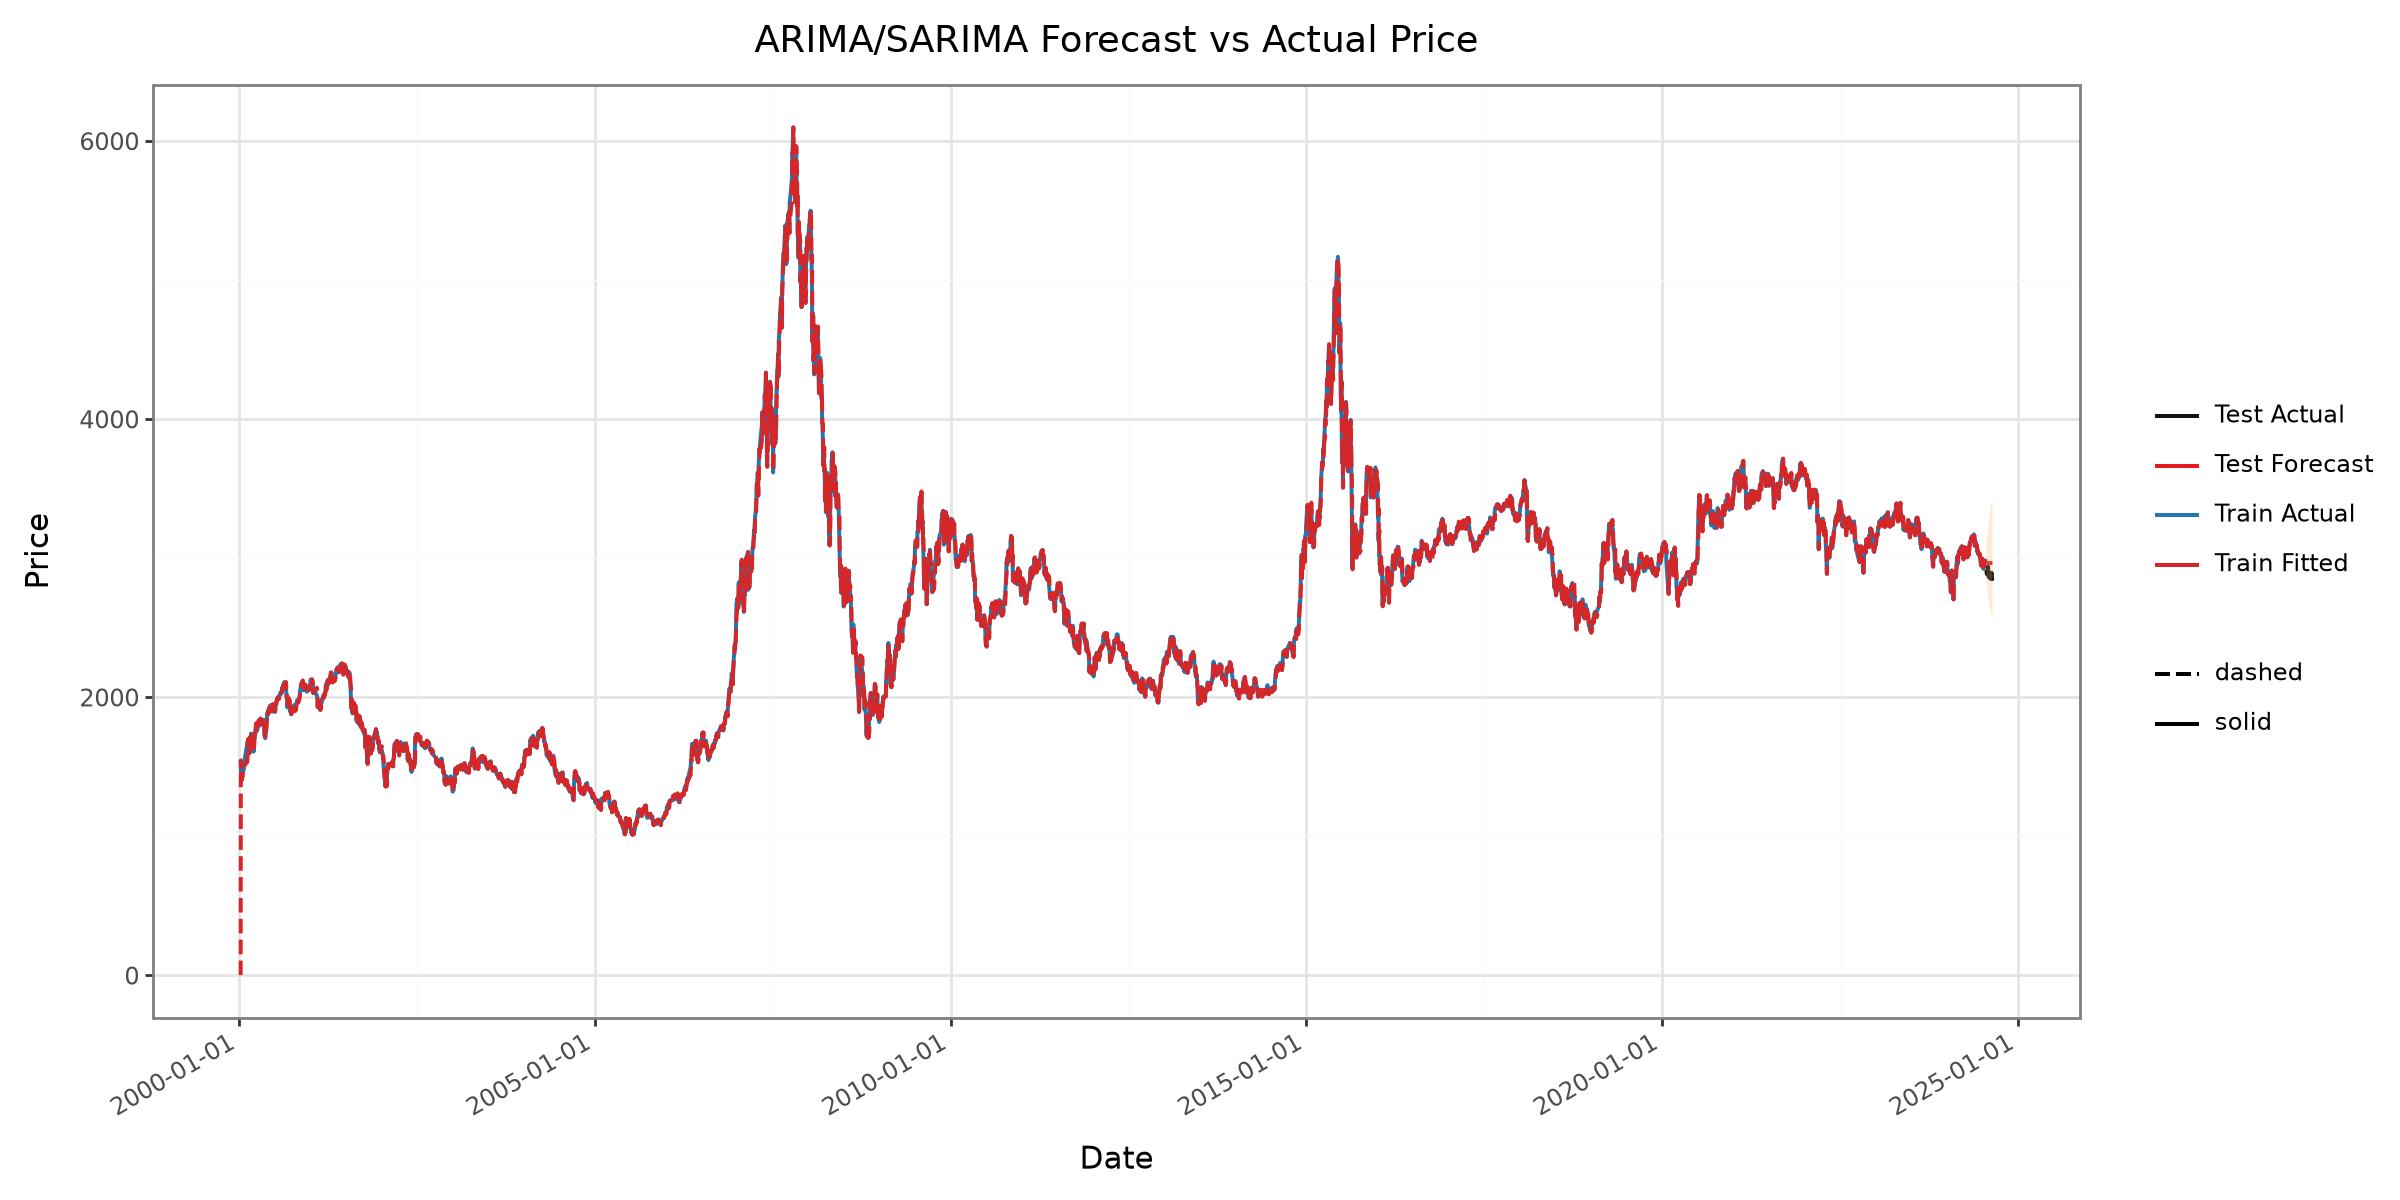

MAE: 83.98920453847897  RMSE: 87.38234225081719


In [256]:
in_sample_df, pred_df, mae, rmse = arima_predict(best_model1, log_train, log_test, inverse='exp', title=None, plot=True)

**小结：** 通用函数得到的结果与前面手动预测基本一致，说明预测流程可以复用到不同频率的数据上。


In [257]:
# In-sample fitted values since 2025
plot_forecast_result(
    in_sample_df,
    pred_df.iloc[0:0],
    title="ARIMA(1,1,5) In-Sample Fit Since 2025",
    focus_start="2025-06-01",
    show_train=True,
    show_interval=False,
)
        


No data to plot for the selected date range.


## 不同时间尺度的时序分析


## 不同时间尺度的时序分析与重新采样

日度价格波动较大，短期噪声会影响模型判断。因此这里把原始日度数据重采样为月度、季度和年度数据，观察低频序列下的趋势和季节性。

对价格序列而言，月末收盘价比月内均值更接近实际投资者在期末观察到的价格，所以后续月度建模使用 `.last()` 作为聚合方式。


### 月度、季度与年度重采样


In [258]:
# 按月、季度、年度重采样。价格序列使用期末值更符合金融含义。
df_m = stock.resample("ME").last()
df_q = stock.resample("QE-DEC").last()
df_y = stock.resample("YE-DEC").last()


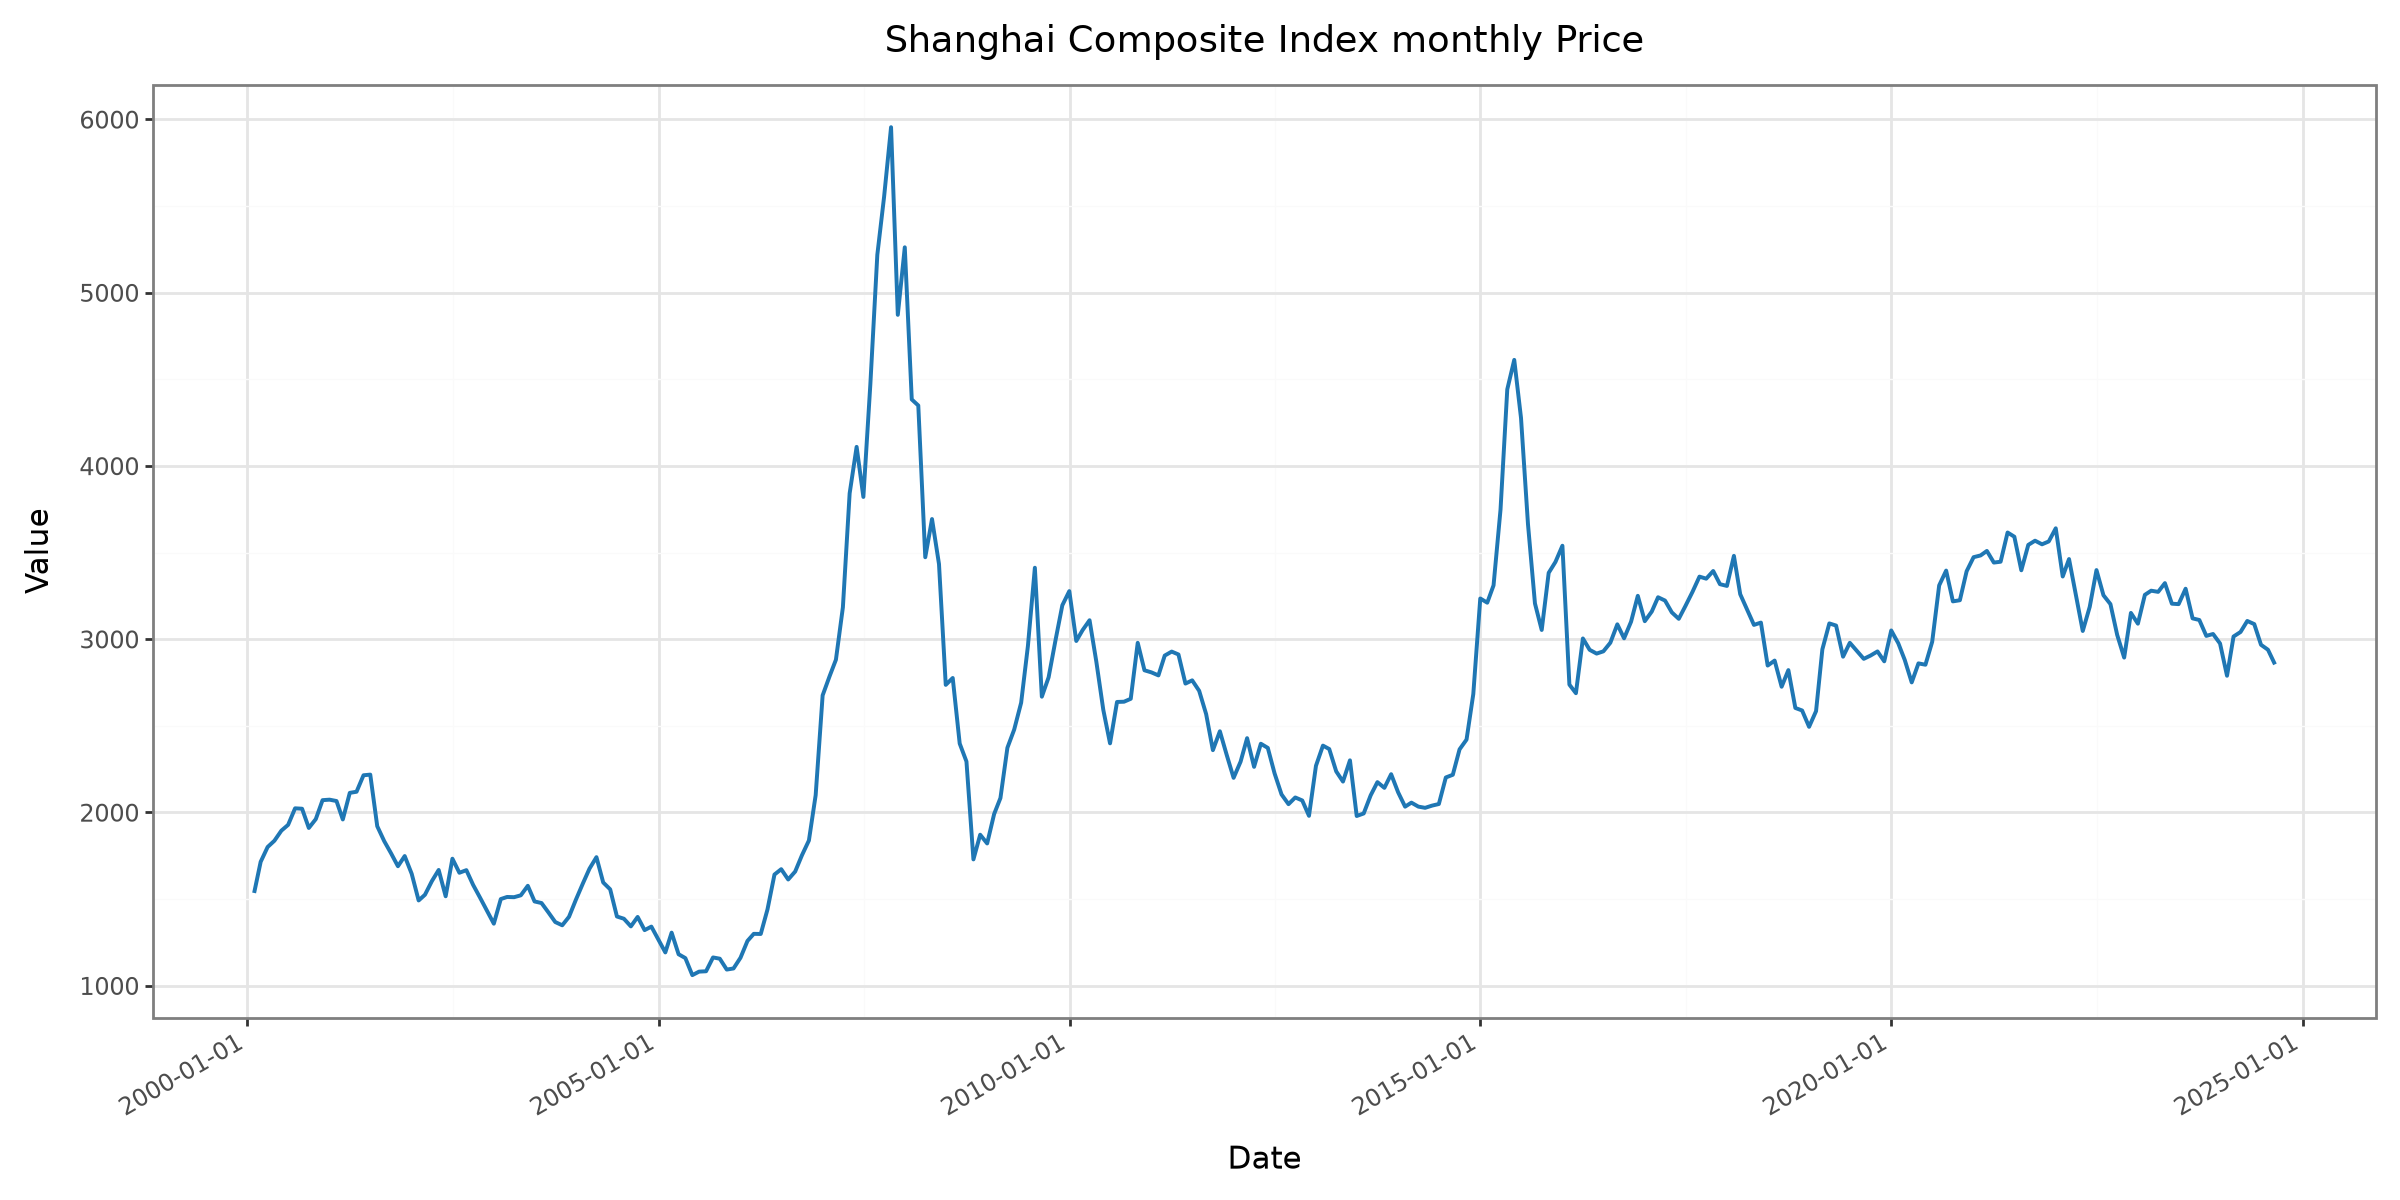

In [259]:
#以下以月度数据进行分析
plot_series(df_m,"Shanghai Composite Index monthly Price")

### 月度数据划分


In [260]:
# step2 分割训练集和测试集
train_m = df_m[:-6]
test_m = df_m[-6:] #预测期是6个月
print(train_m)
print(test_m)

            close_price
date                   
2000-01-31     1535.000
2000-02-29     1714.580
2000-03-31     1800.220
2000-04-30     1836.320
2000-05-31     1894.550
...                 ...
2023-10-31     3018.771
2023-11-30     3029.673
2023-12-31     2974.935
2024-01-31     2788.548
2024-02-29     3015.171

[290 rows x 1 columns]
            close_price
date                   
2024-03-31     3041.167
2024-04-30     3104.825
2024-05-31     3086.813
2024-06-30     2967.403
2024-07-31     2938.749
2024-08-31     2854.368


### 月度序列诊断


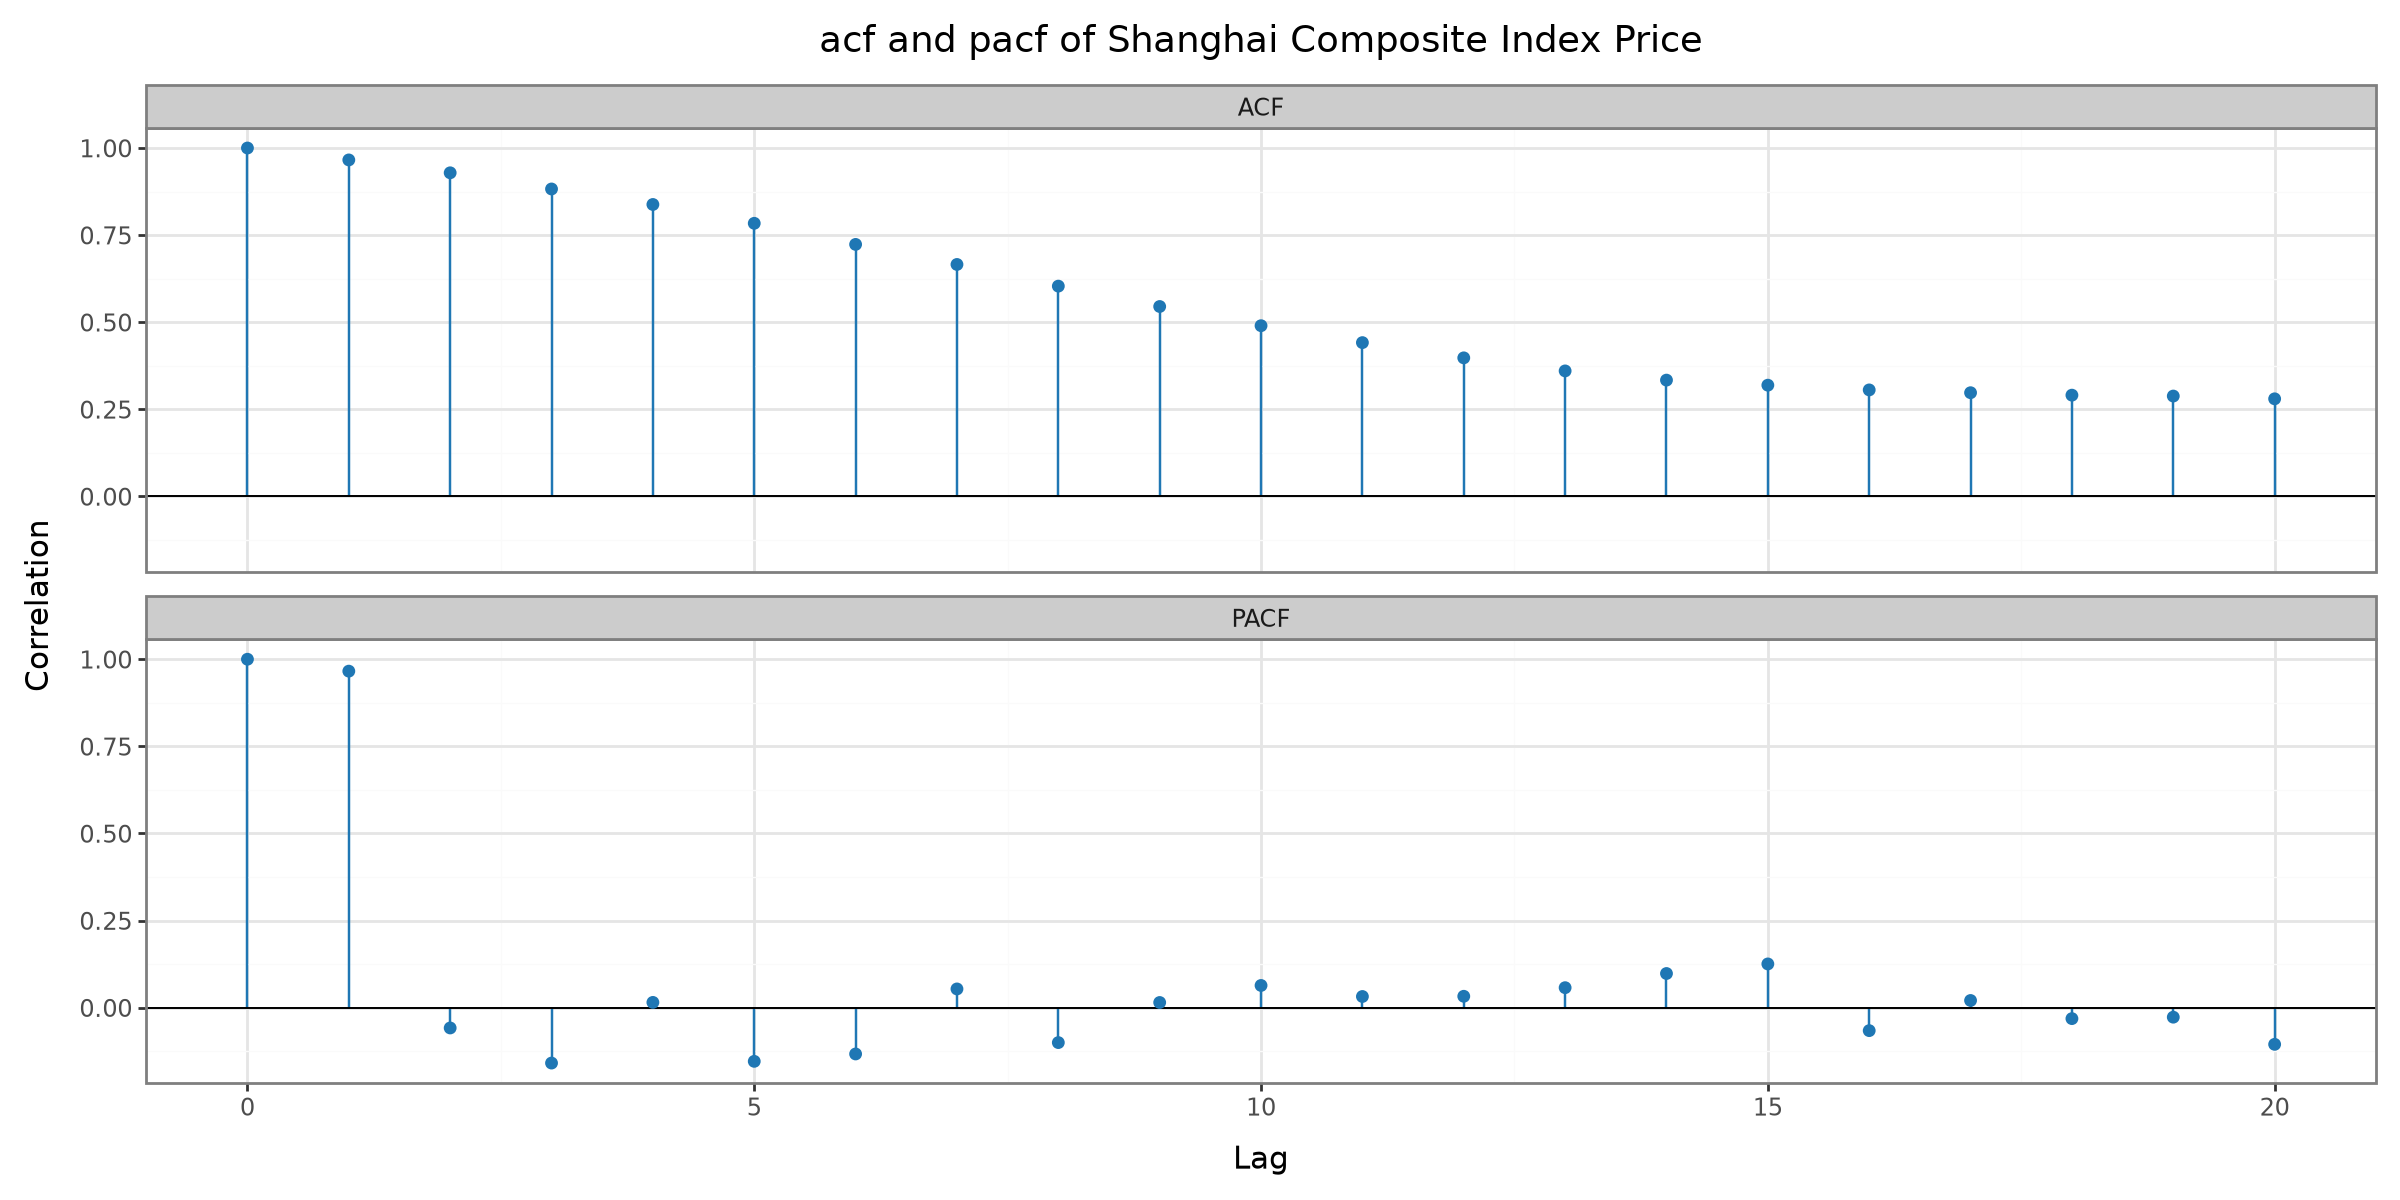

In [261]:
#  观察自相关图，初步判断数据的平稳性或季节性
plot_acf_pacf(train_m,"acf and pacf of Shanghai Composite Index Price")

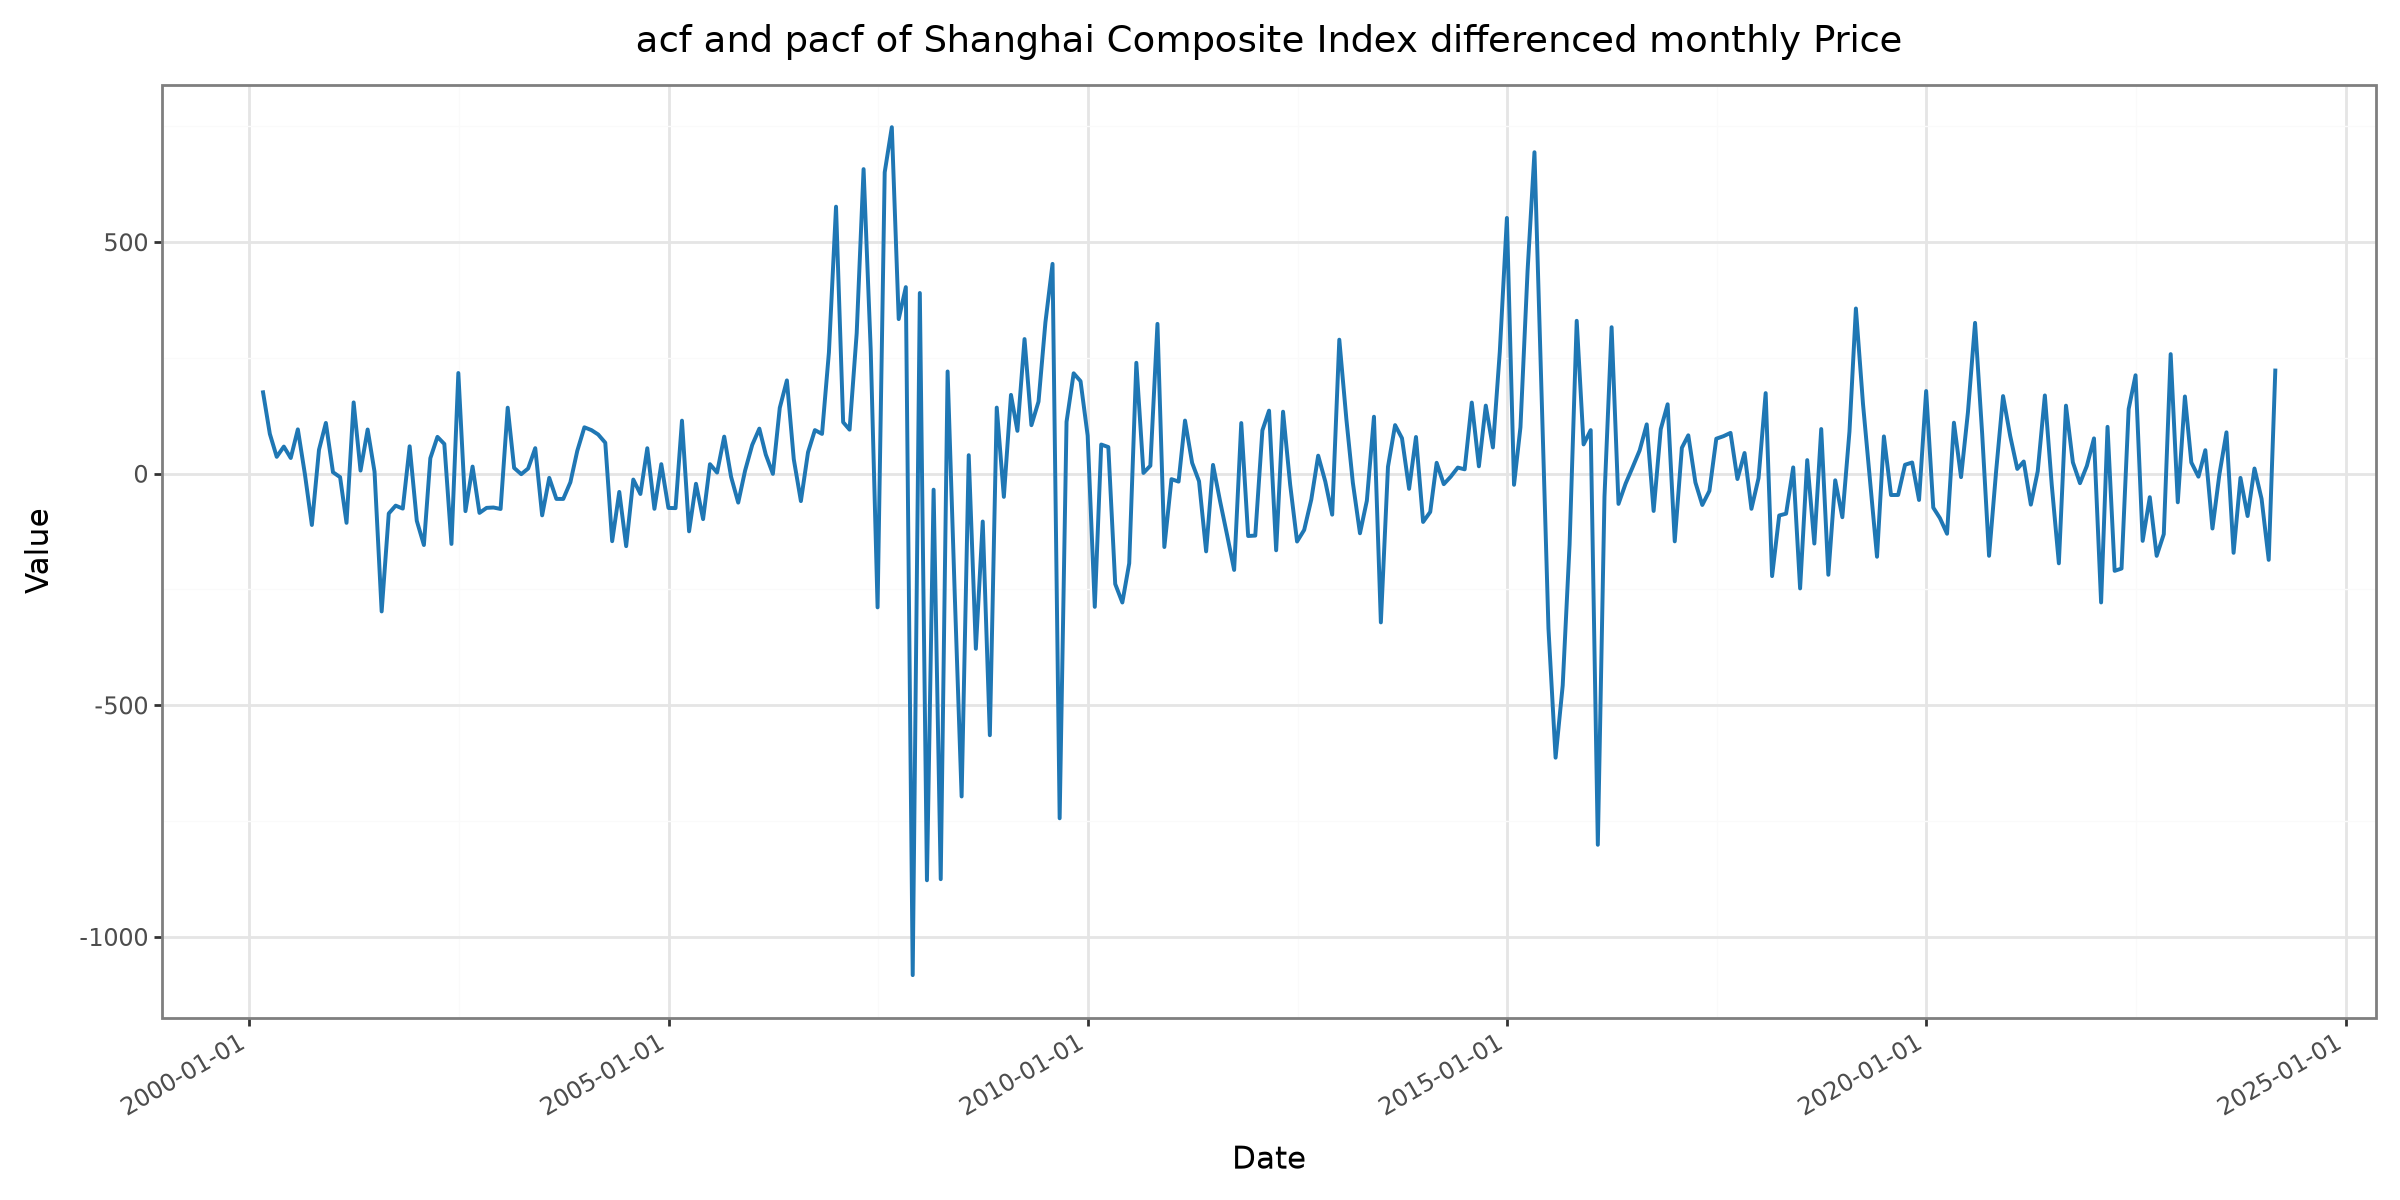

In [262]:
# 观察差分序列
diff_df = train_m.diff()
plot_series(diff_df,"acf and pacf of Shanghai Composite Index differenced monthly Price")

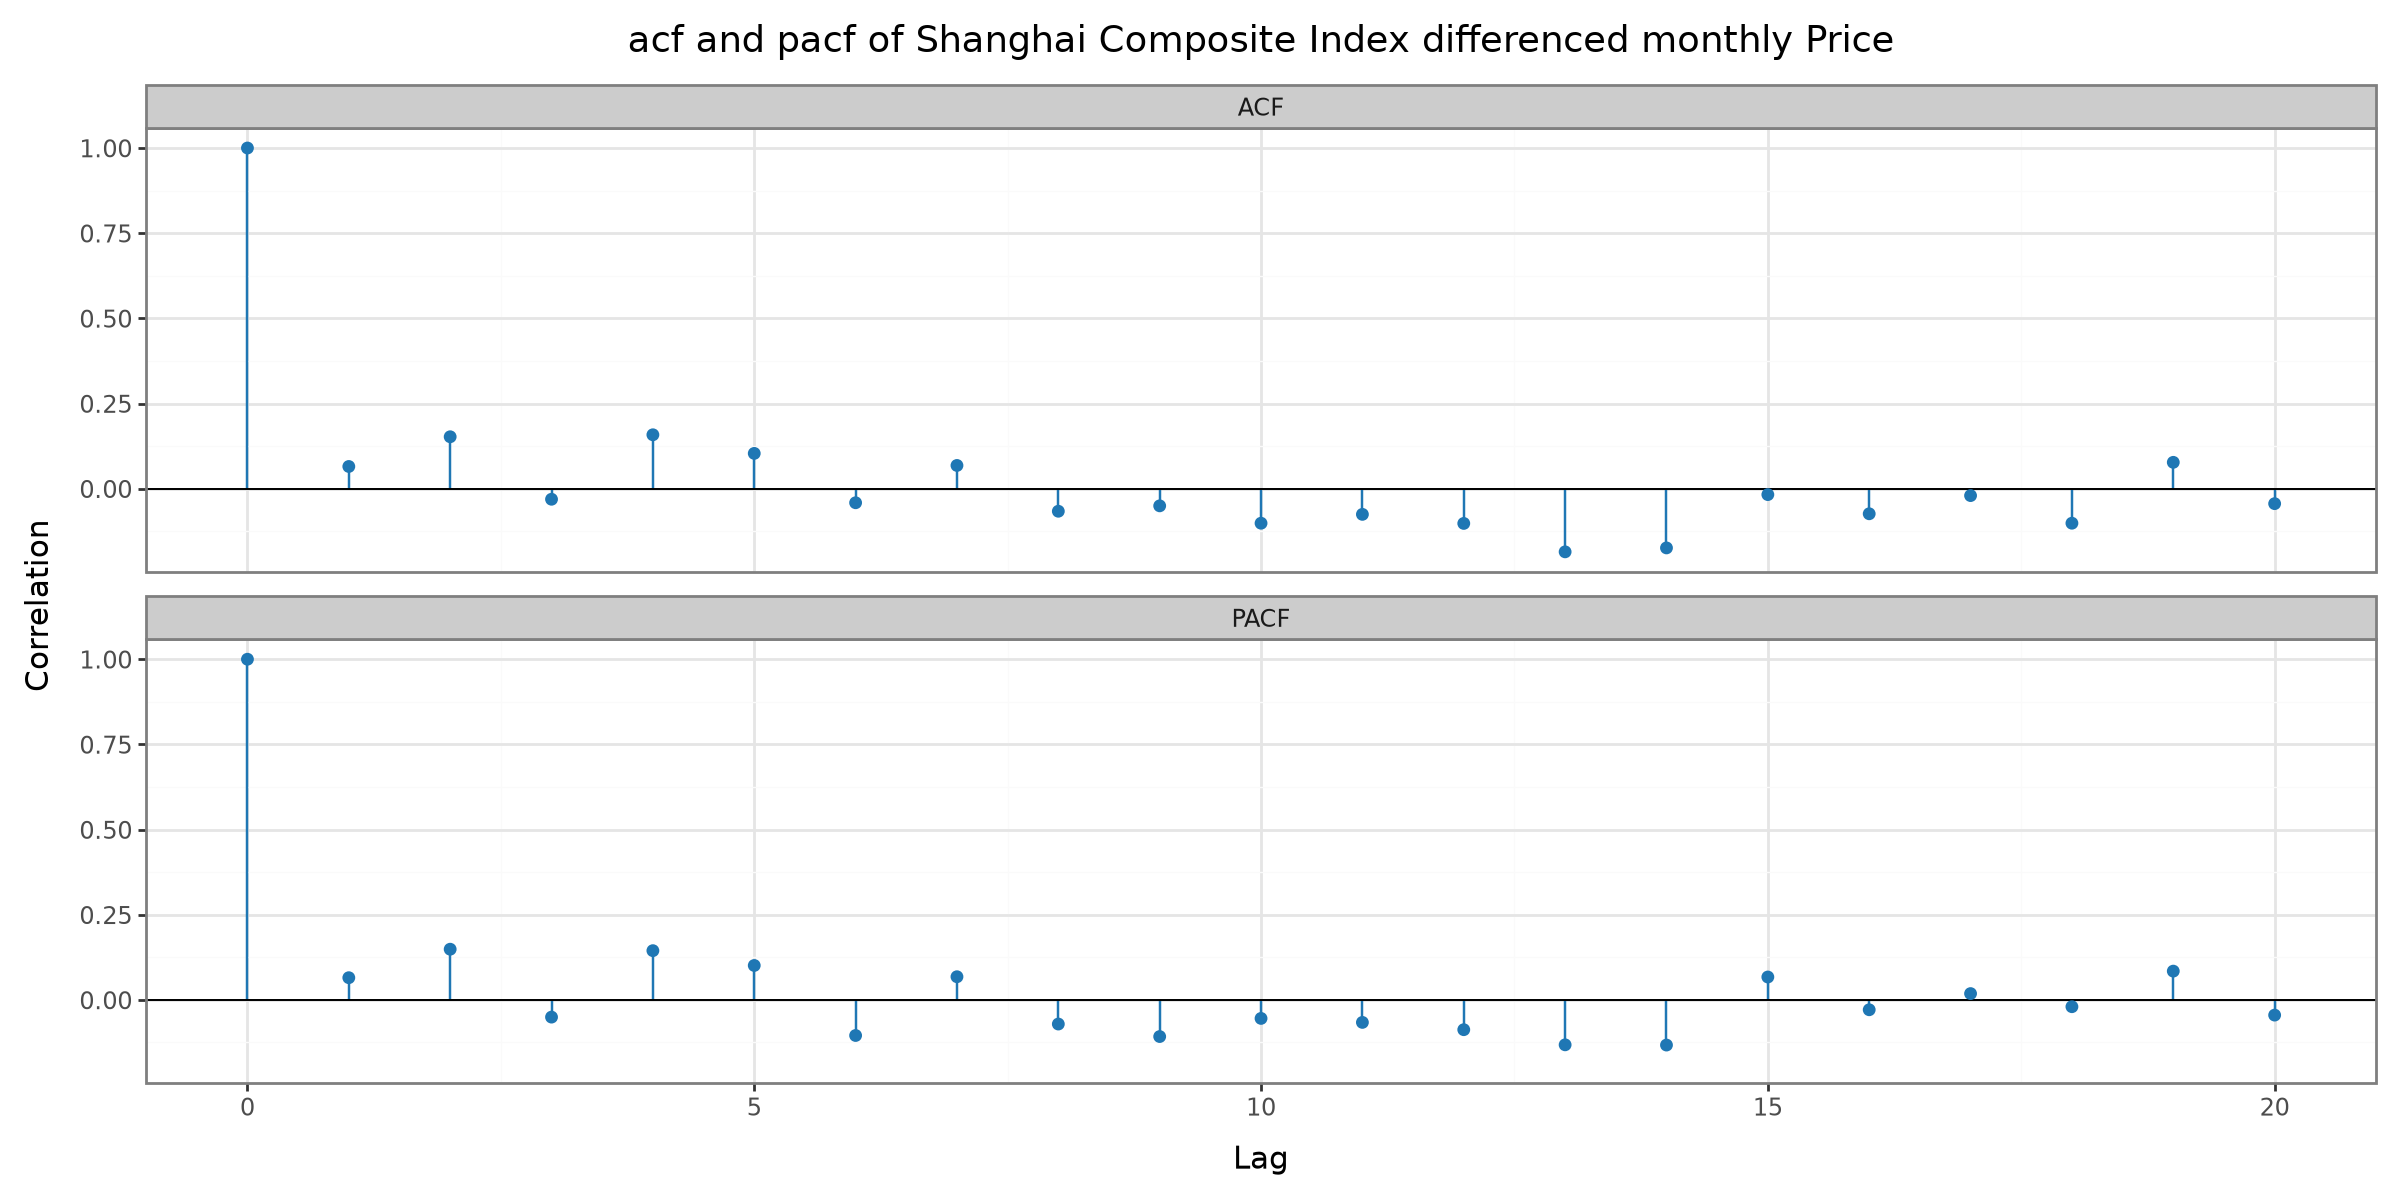

In [263]:
# 观察差分序列的自相关图
ddf = diff_df.dropna()
plot_acf_pacf(ddf,"acf and pacf of Shanghai Composite Index differenced monthly Price")

#通过观察，差分序列应该存在季节性

### 月度模型筛选与检验


In [264]:
# 月度数据样本较少，搜索范围不宜过大
mbest_model, mbest_param, mresults_df = select_best_sarimax(
    train_m, p_max=4, d_max=1, q_max=5, seasonal_order=(1, 0, 0, 12)
)

print(mbest_model.summary())
print(mresults_df.head())


最优模型参数: (4, 1, 4)  AIC: 3710.9857341985216
                                      SARIMAX Results                                      
Dep. Variable:                         close_price   No. Observations:                  290
Model:             SARIMAX(4, 1, 4)x(1, 0, [], 12)   Log Likelihood               -1845.493
Date:                             Sat, 15 Aug 2026   AIC                           3710.986
Time:                                     12:38:26   BIC                           3747.080
Sample:                                 01-31-2000   HQIC                          3725.475
                                      - 02-29-2024                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6229      0.181      3.449      0.001       0.

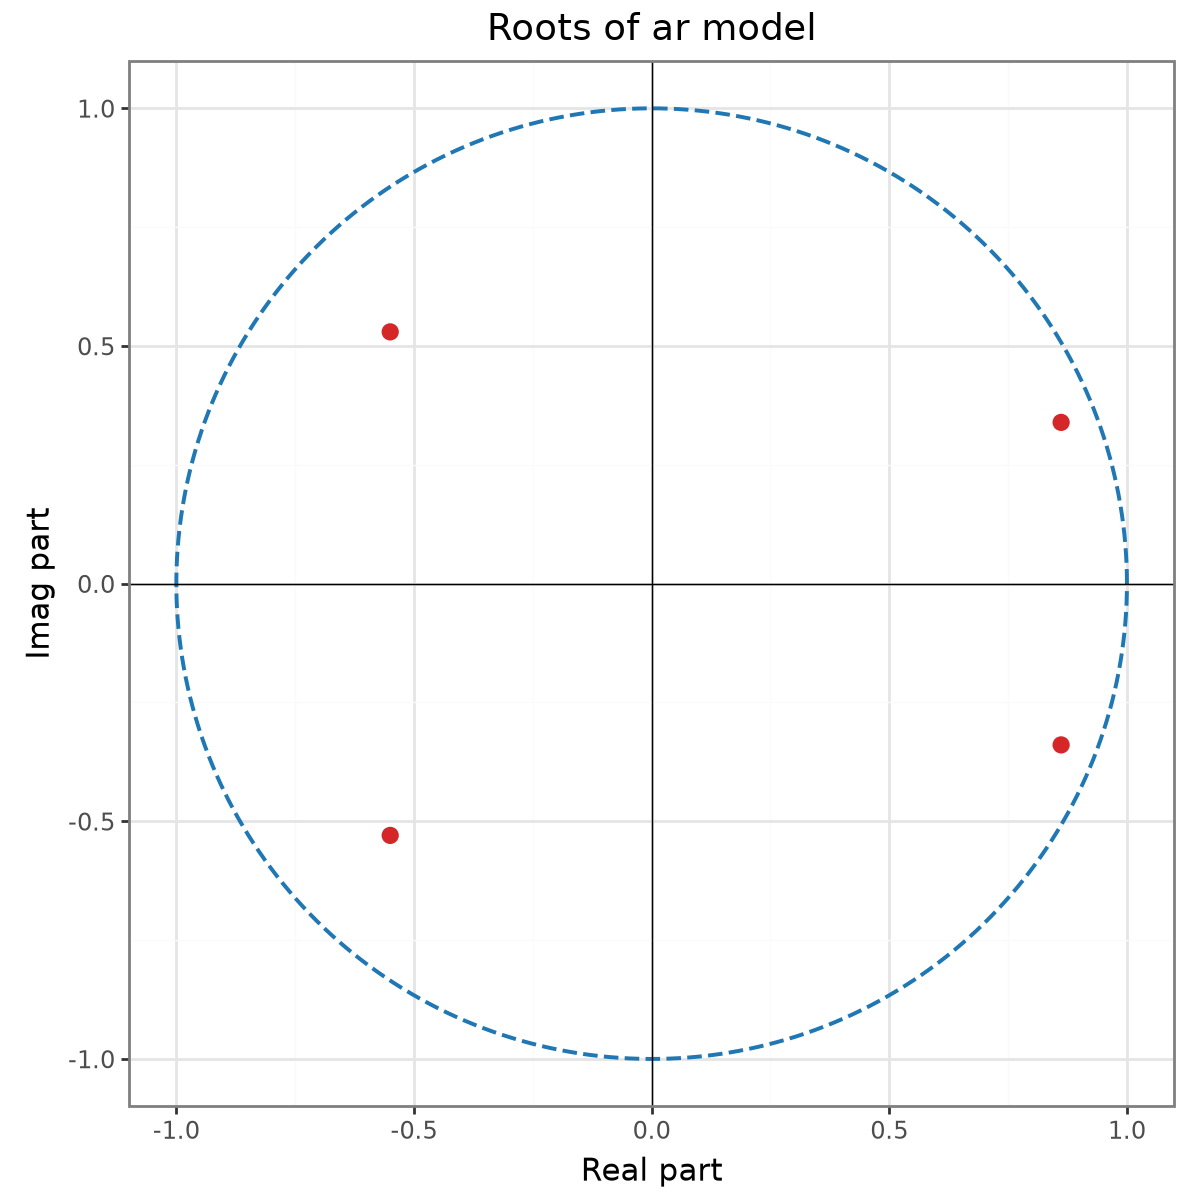

Roots: [ 0.86151396+0.33928017j  0.86151396-0.33928017j -0.55004392+0.52969275j
 -0.55004392-0.52969275j]
Modulus: [0.92591433 0.92591433 0.76362473 0.76362473]


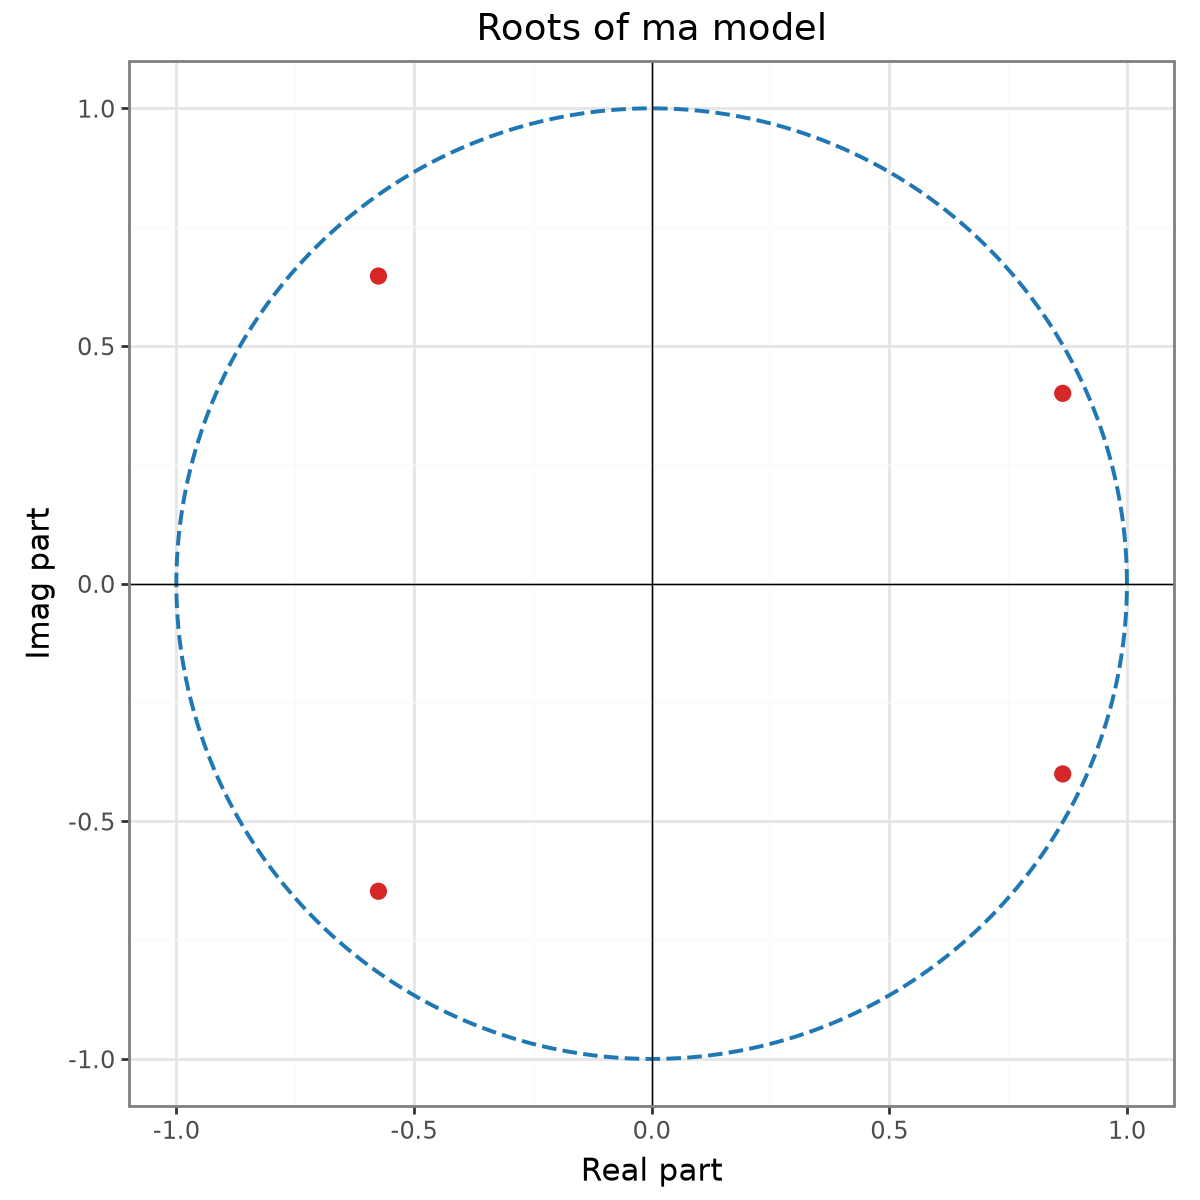

Roots: [-0.57479153+0.6471512j  -0.57479153-0.6471512j   0.86491785+0.40037652j
  0.86491785-0.40037652j]
Modulus: [0.86555761 0.86555761 0.95309194 0.95309194]


In [265]:
#step4 进行平稳性和可逆性检验
phi = np.array([val for name, val in mbest_model.params.items() if "ar." in name and "S" not in name])
theta = np.array([val for name, val in mbest_model.params.items() if "ma." in name and "S" not in name])

ar_poly = np.r_[1, -phi]       # [1, -phi1, -phi2, ...]
ma_poly = np.r_[1,  theta]     # [1,  theta1, theta2, ...]


plot_roots_simple(ar_poly, "Roots of ar model")
plot_roots_simple(ma_poly, "Roots of ma model")

In [266]:
# 获得残差，并进行独立性检验
resid = mbest_model.resid
lb = acorr_ljungbox(resid, lags=[6, 12], return_df=True, model_df=2)
print(lb)

     lb_stat  lb_pvalue
6   2.901912   0.574372
12  3.538794   0.965765


### 月度预测与可视化


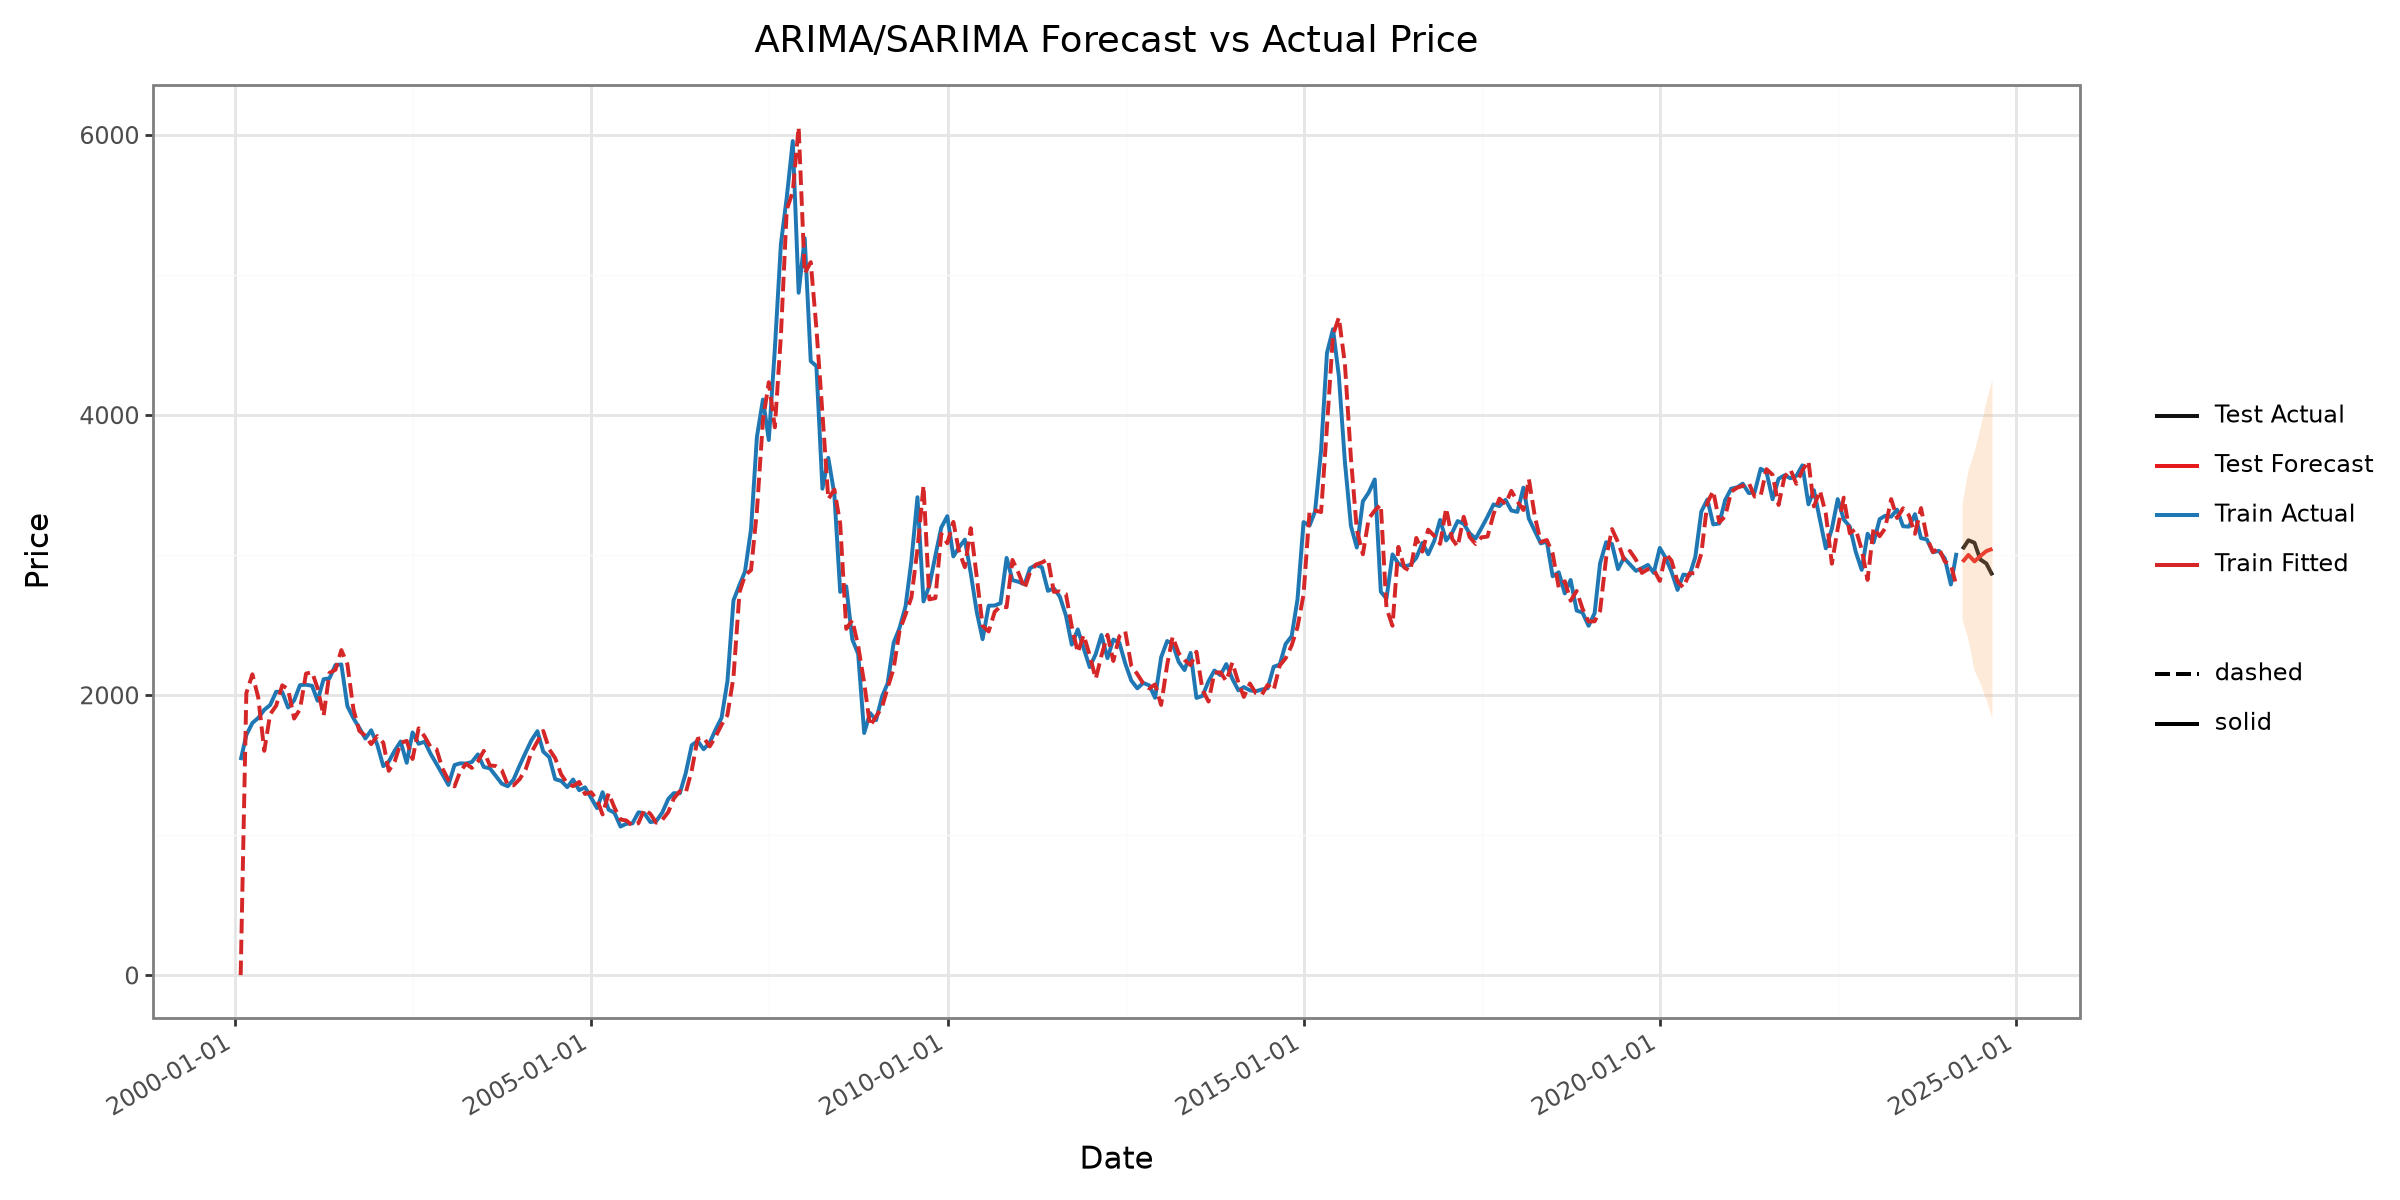

MAE: 105.22258135640352  RMSE: 116.33068926731978


In [267]:
# step5 预测和可视化
in_sample_df, pred_df, mae, rmse = arima_predict(mbest_model, train_m, test_m, inverse='none', title=None, plot=True)

**小结：** 月度序列噪声更低，预测曲线通常更平滑，但样本数量也明显减少。因此月度模型更适合观察中期趋势，不适合过度解读短期交易信号。


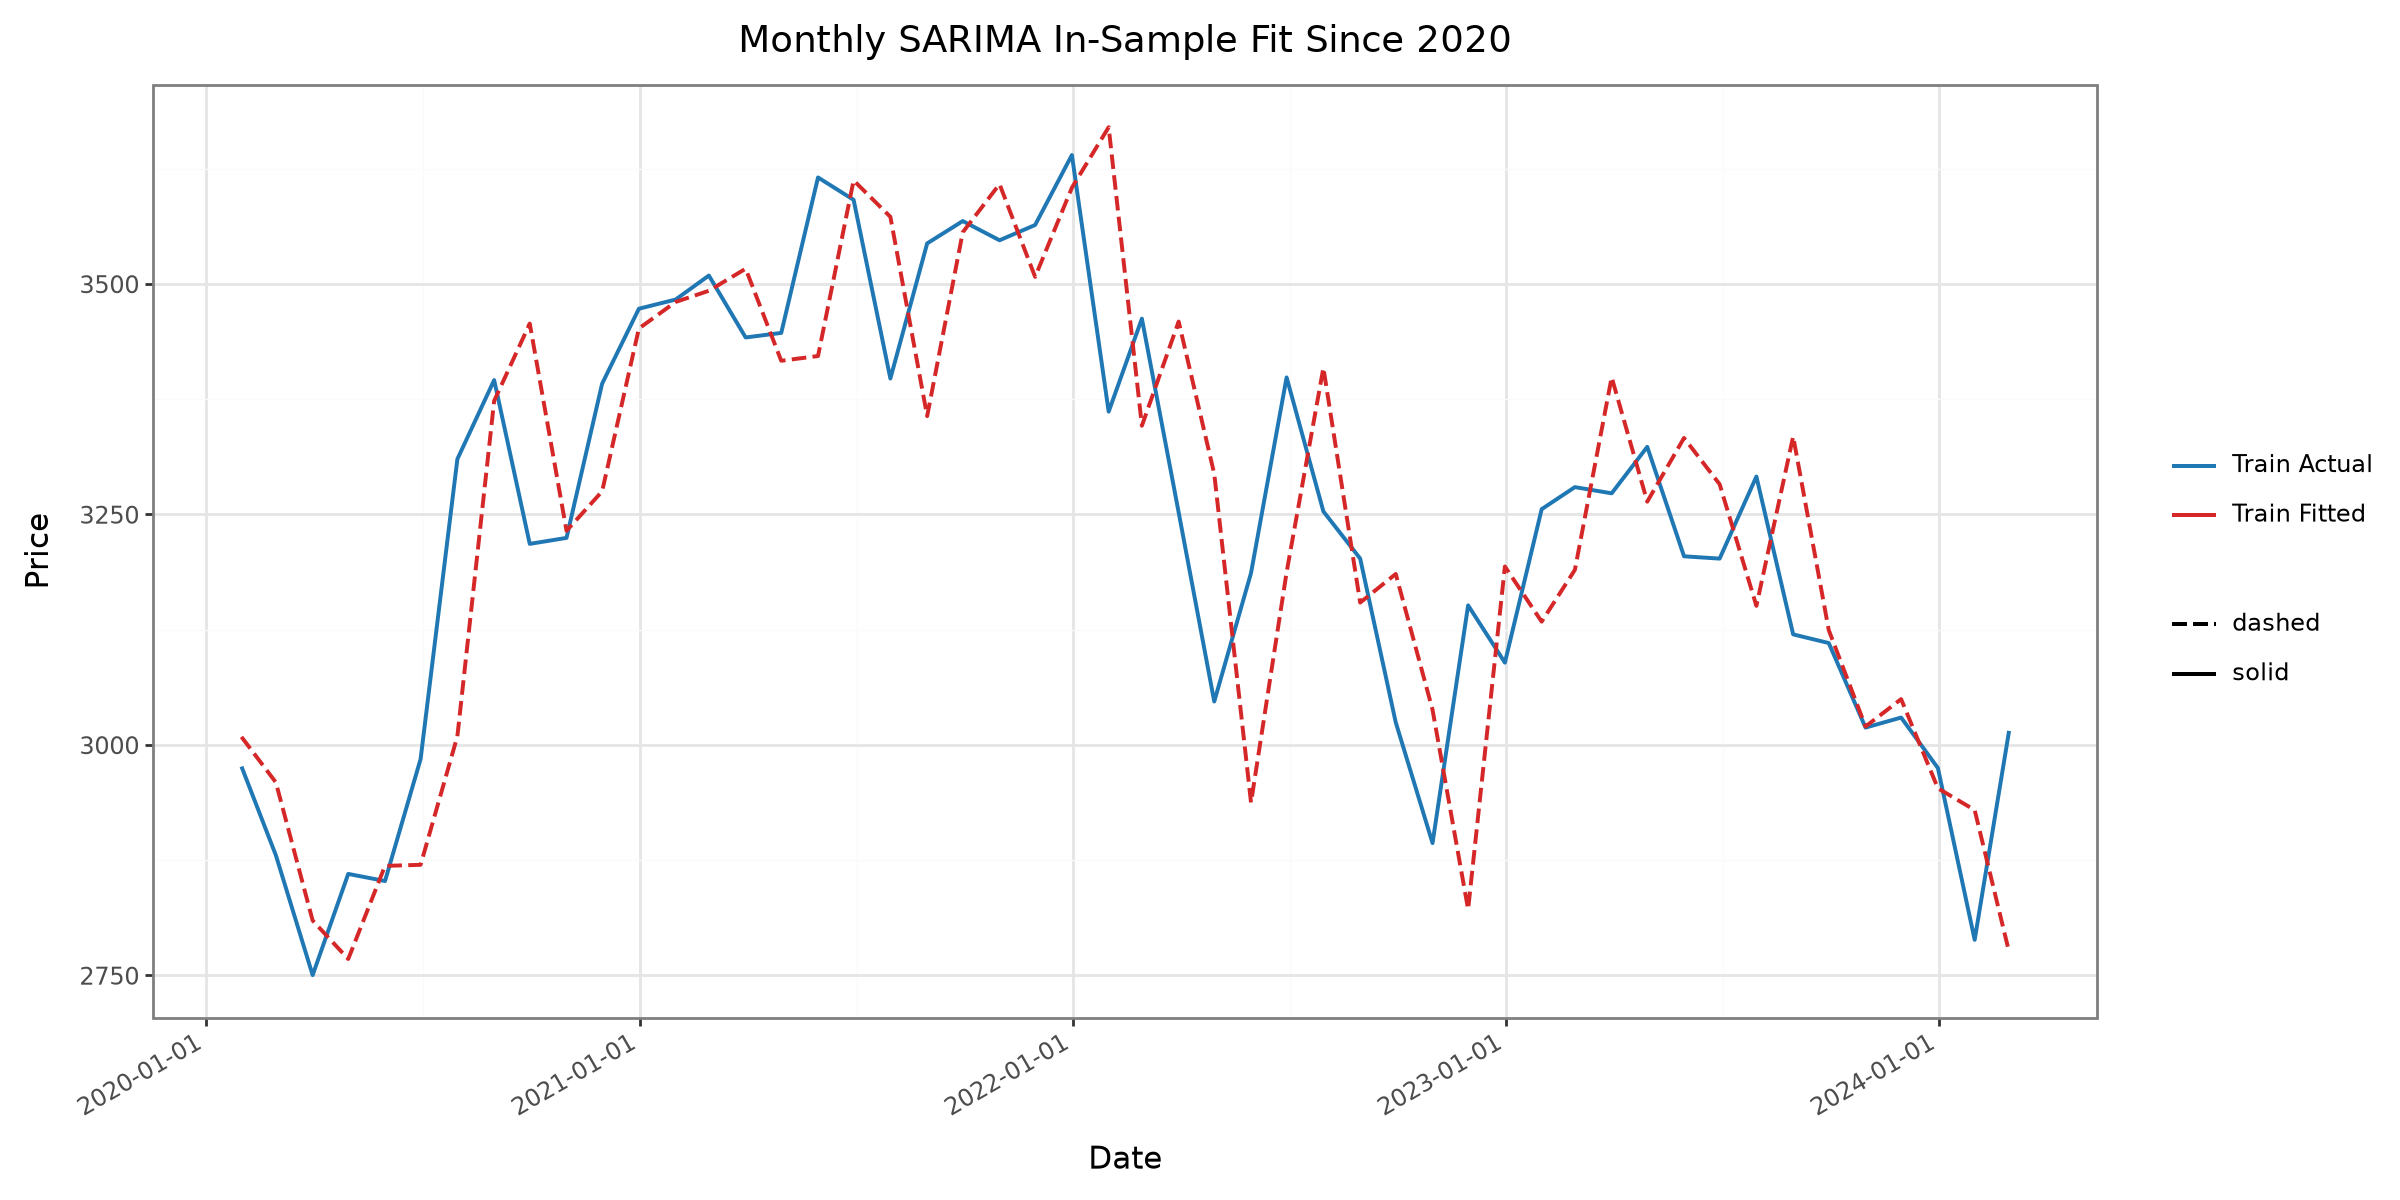

In [268]:
# Monthly in-sample fitted values since 2020
plot_forecast_result(
    in_sample_df,
    pred_df.iloc[0:0],
    title="Monthly SARIMA In-Sample Fit Since 2020",
    focus_start="2020-01-31",
    show_train=True,
    show_interval=False,
)
        


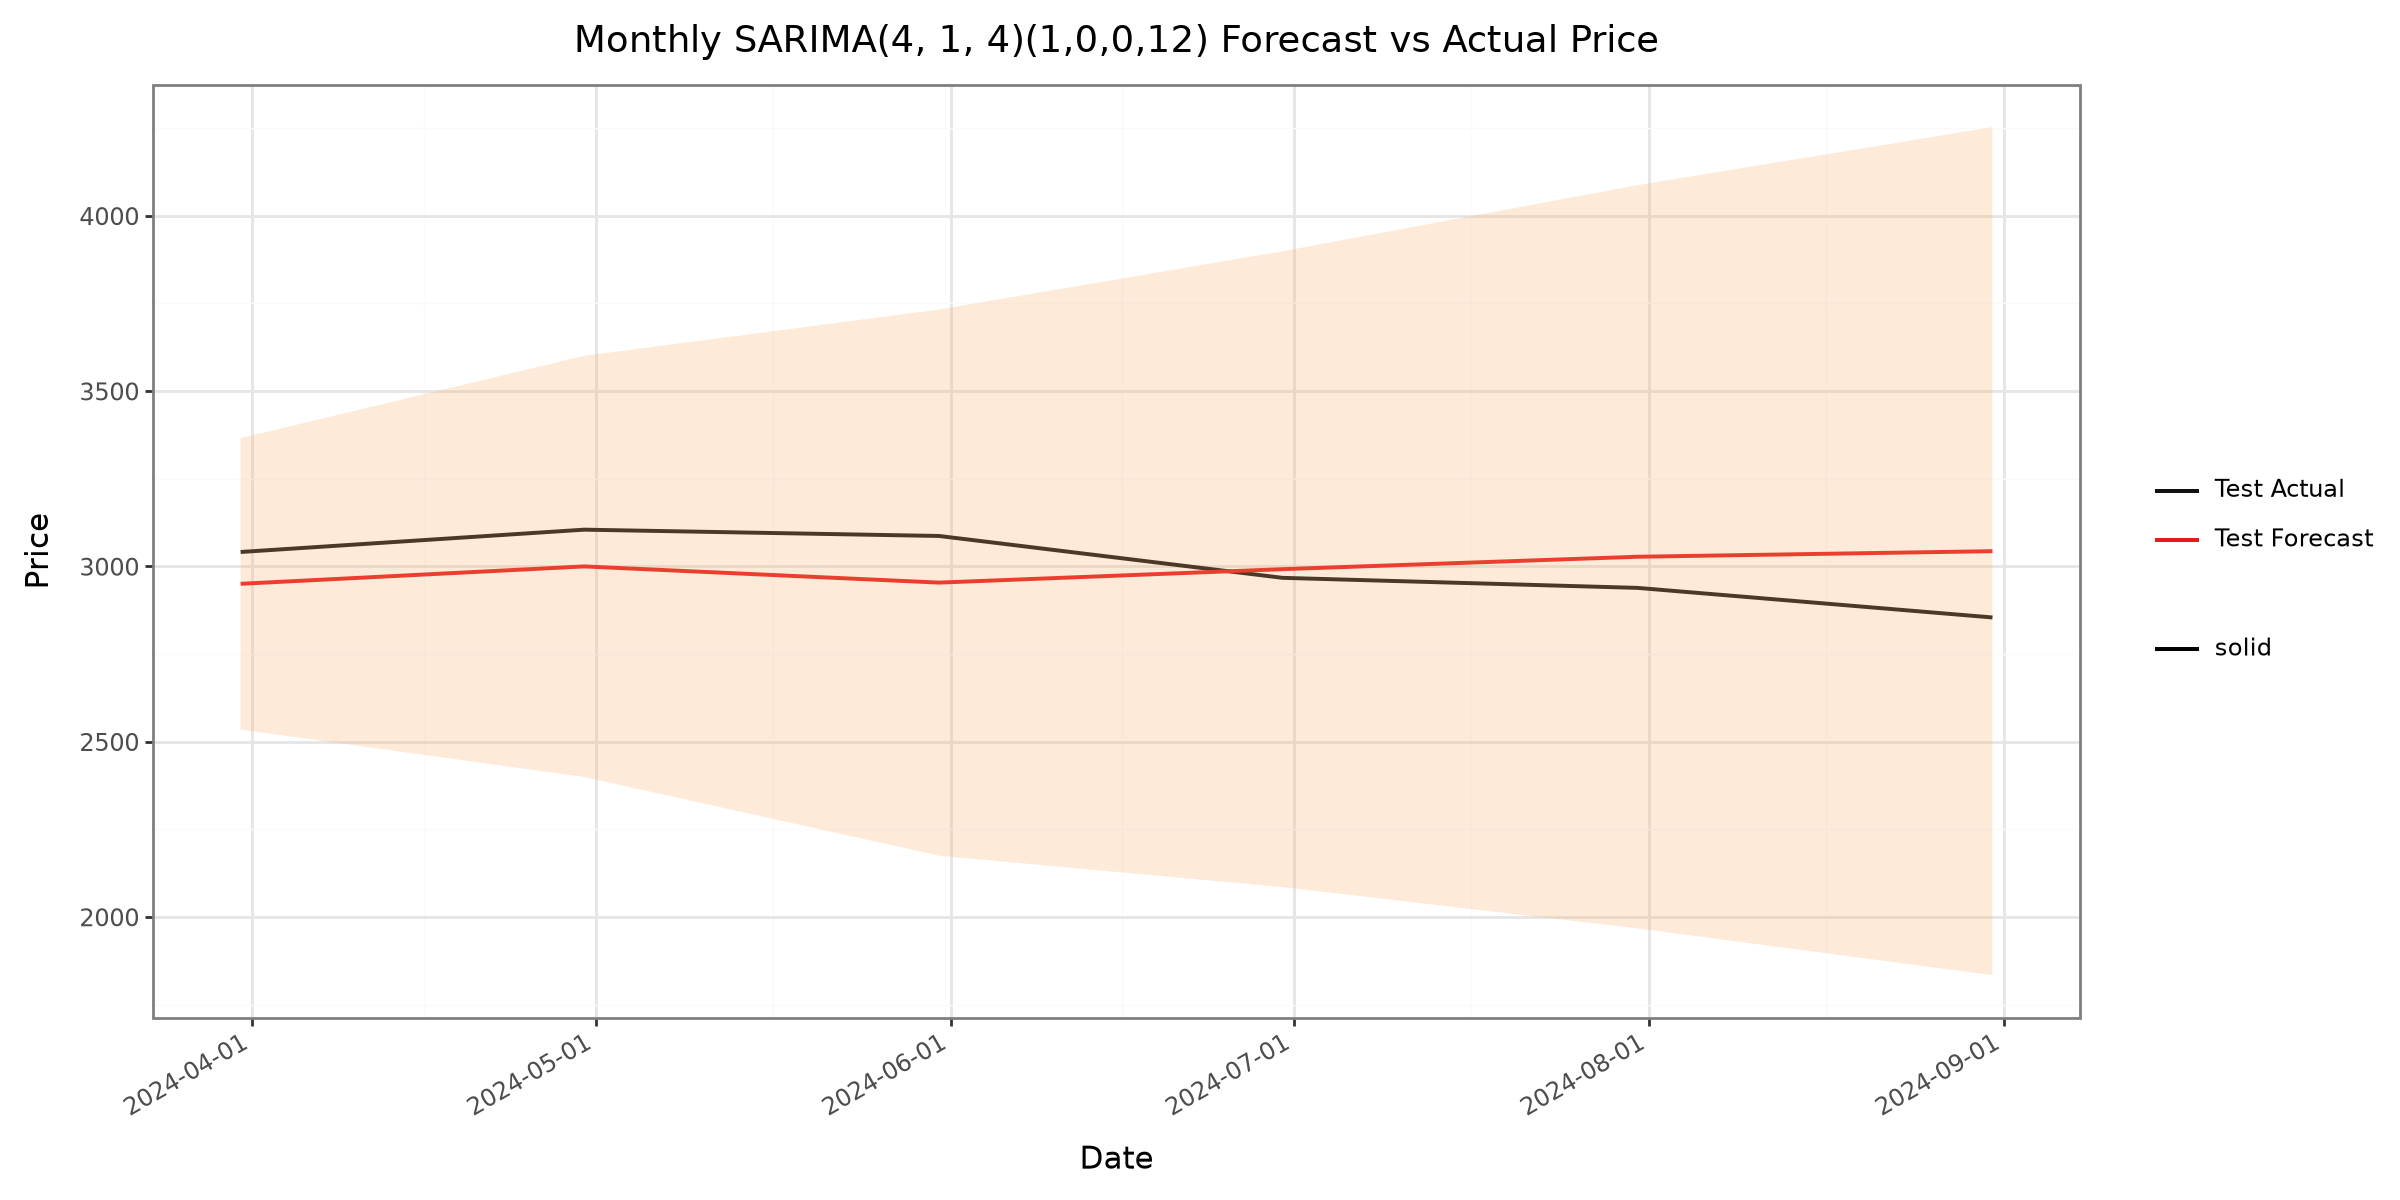

In [269]:
# Monthly test-set actual values and forecasts
plot_forecast_result(
    in_sample_df.iloc[0:0],
    pred_df,
    title=f"Monthly SARIMA{mbest_param}(1,0,0,12) Forecast vs Actual Price",
    show_train=False,
    show_interval=True,
)
        


## 量化评估：收益率预测与简单回测

价格预测只能说明模型能否拟合指数点位，但量化应用更关心收益率方向和策略表现。因此最后补充一个简单检验：用滚动 ARIMA 预测下一期收益率，并与朴素预测、20 日均值和漂移项基准比较。


### 构建收益率序列

这里使用对数收益率而不是价格水平。收益率更接近平稳序列，也更适合用于方向预测和回测。


Sample period: 2000-01-10 00:00:00 to 2024-08-23 00:00:00
Price observations: 5971 Return observations: 5970


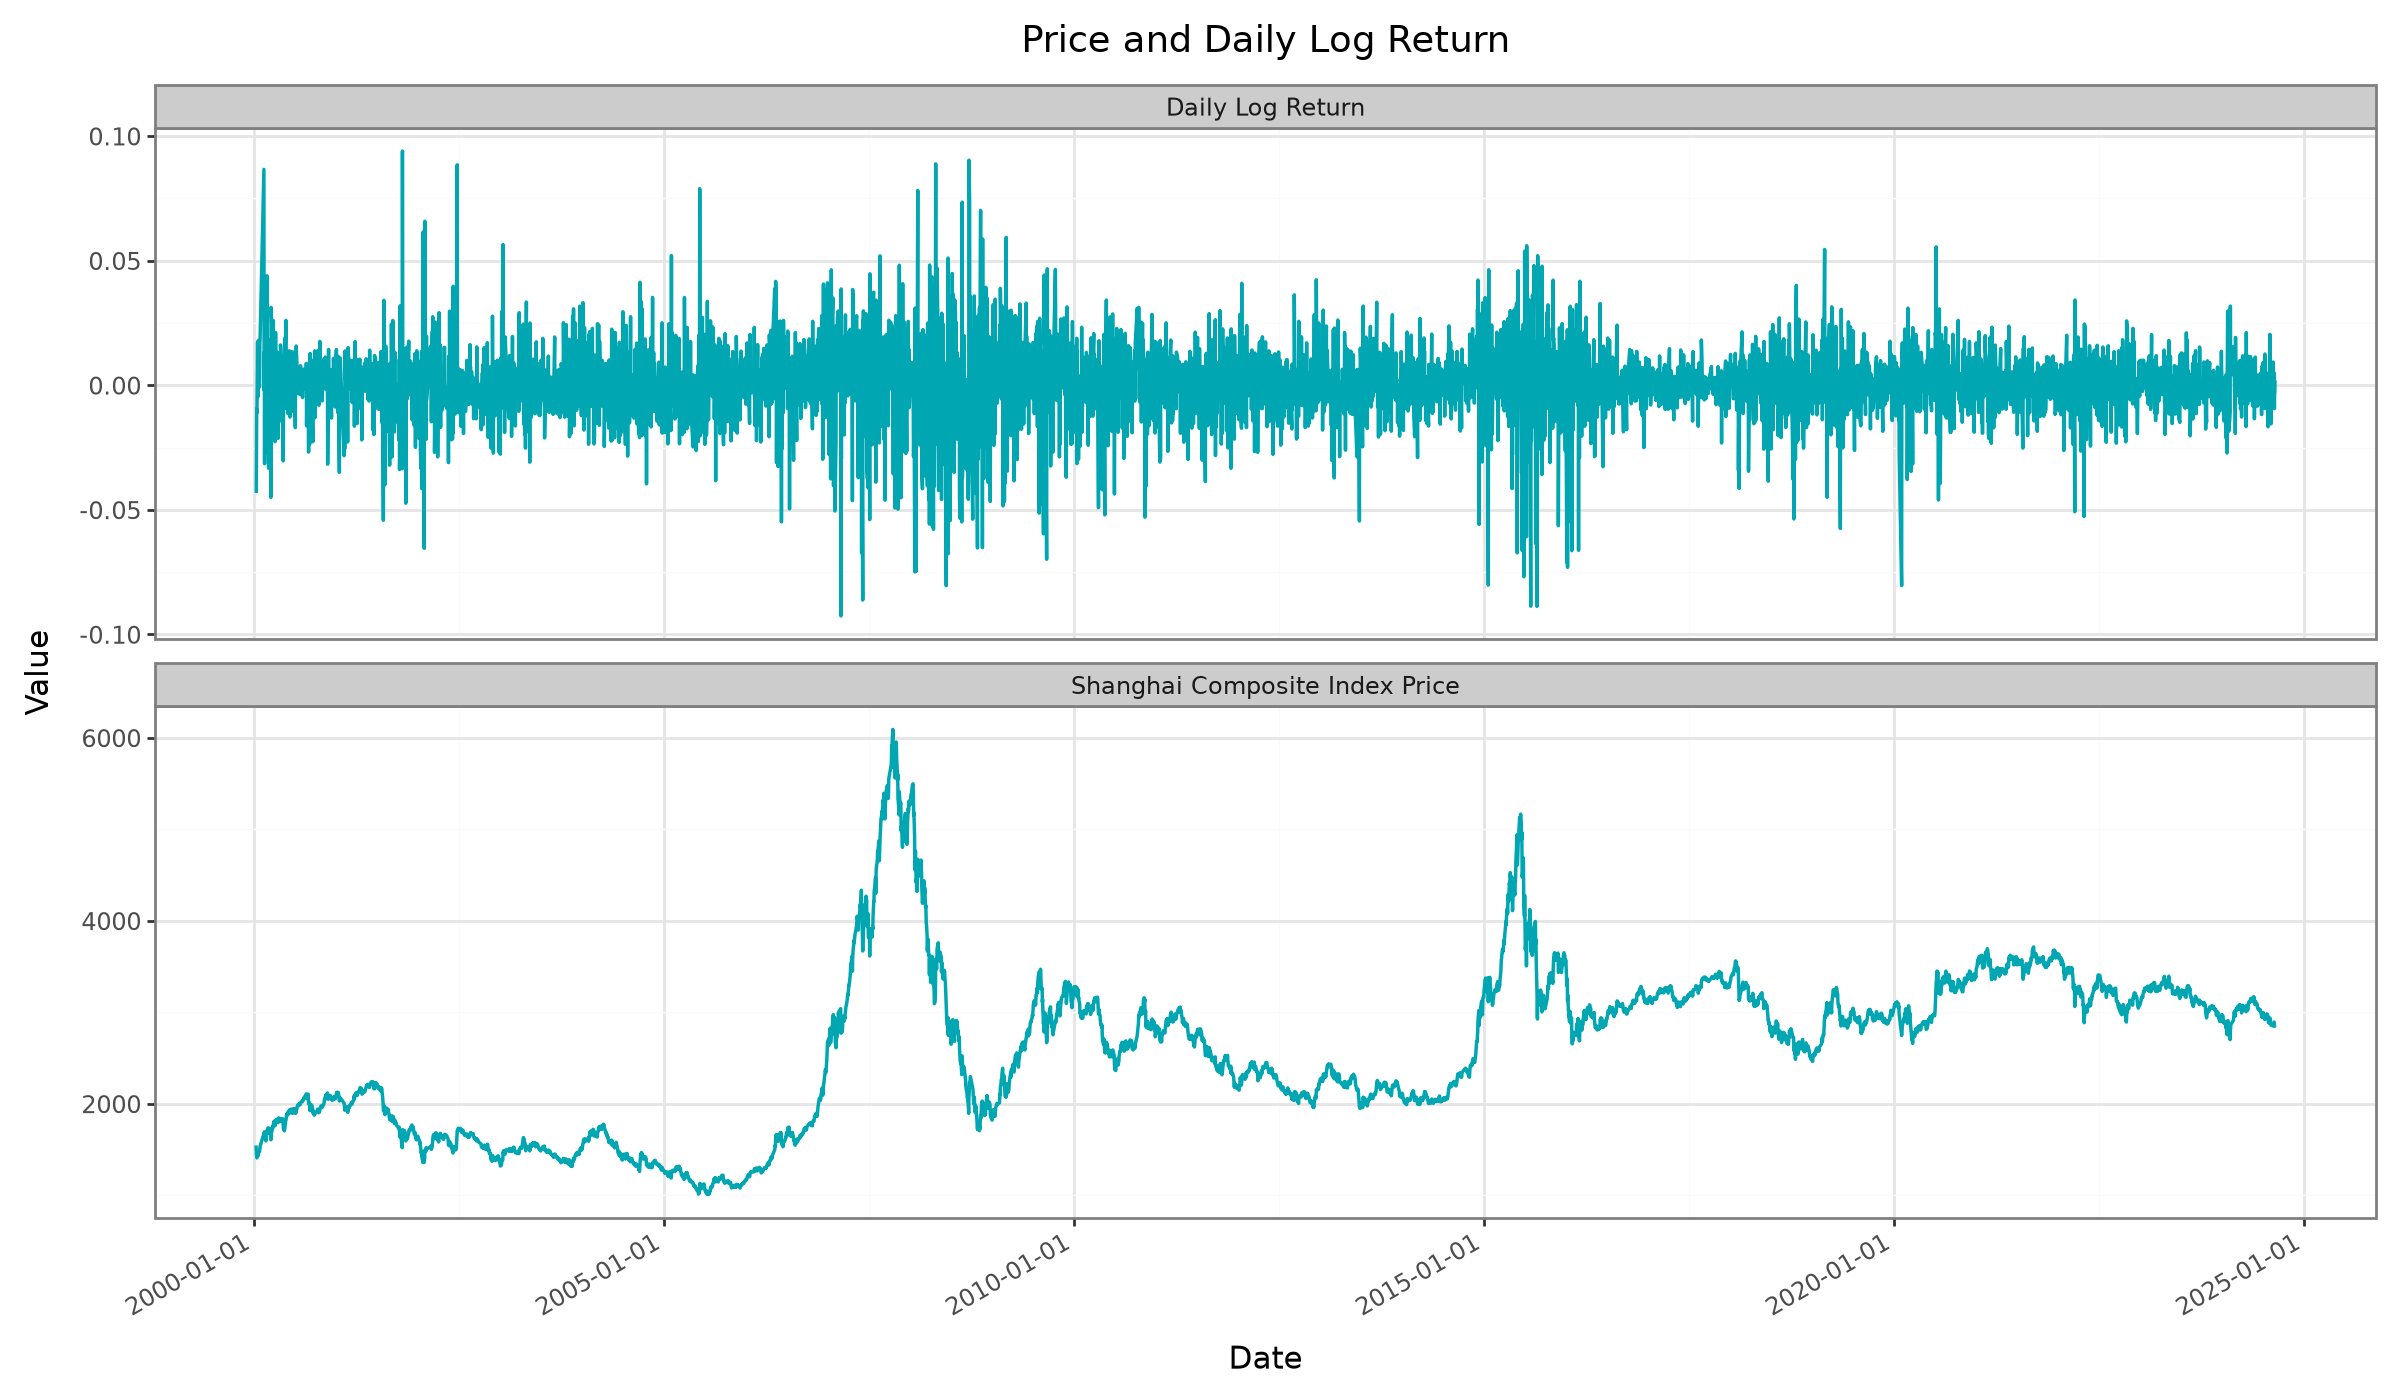

In [270]:
price = stock["close_price"].dropna().sort_index().astype(float)
log_price = np.log(price)
log_return = log_price.diff().dropna()

print("Sample period:", price.index.min(), "to", price.index.max())
print("Price observations:", len(price), "Return observations:", len(log_return))

return_plot_df = pd.concat([
    price.rename("Shanghai Composite Index Price"),
    log_return.rename("Daily Log Return"),
], axis=1)
return_plot_df.index.name = "date"

return_plot_long = (
    return_plot_df
    .reset_index()
    .melt(id_vars="date", var_name="series", value_name="value")
    .dropna(subset=["value"])
)

p = (
    ggplot(return_plot_long, aes("date", "value"))
    + geom_line(color="#00A6B2", size=0.7)
    + facet_wrap("~series", ncol=1, scales="free_y")
    + labs(title="Price and Daily Log Return", x="Date", y="Value")
    + theme_bw()
    + theme(figure_size=(12, 7), axis_text_x=element_text(rotation=30, ha="right"))
)
display(p)


### 基准模型

设置三个简单基准：上一日收益率、过去 20 日平均收益率、训练集平均收益率。只有超过这些基准，复杂模型才有实际意义。


In [271]:
test_size = min(252, max(60, len(log_return) // 5))
ret_train = log_return.iloc[:-test_size]
ret_test = log_return.iloc[-test_size:]

forecast_df = pd.DataFrame(index=ret_test.index)
forecast_df["actual_return"] = ret_test
forecast_df["naive"] = log_return.shift(1).reindex(ret_test.index)
forecast_df["ma20"] = log_return.rolling(20).mean().shift(1).reindex(ret_test.index)
forecast_df["drift"] = ret_train.mean()
forecast_df = forecast_df.dropna()

forecast_df.head()


,actual_return,naive,ma20,drift
date,,,,
2023-08-11,-0.020272,0.003100,0.000279,0.00013
2023-08-14,-0.003399,-0.020272,-0.000754,0.00013
2023-08-15,-0.000708,-0.003399,-0.000488,0.00013
2023-08-16,-0.008235,-0.000708,-0.000340,0.00013
2023-08-17,0.004311,-0.008235,-0.000767,0.00013


### 基准模型评估


In [272]:
def regression_metrics(y_true, y_pred):
    err = y_true - y_pred
    return pd.Series({
        "MAE": err.abs().mean(),
        "RMSE": np.sqrt((err ** 2).mean()),
        "DirectionAcc": (np.sign(y_true) == np.sign(y_pred)).mean(),
    })

baseline_metrics = pd.DataFrame({
    name: regression_metrics(forecast_df["actual_return"], forecast_df[name])
    for name in ["naive", "ma20", "drift"]
}).T

baseline_metrics


,MAE,RMSE,DirectionAcc
naive,0.008946,0.011529,0.460317
ma20,0.006507,0.008556,0.492063
drift,0.006370,0.008360,0.488095


### 滚动 ARIMA 收益率预测

为了避免未来信息泄露，每个测试日只使用该日之前的数据重新估计模型，并预测下一期收益率。


In [273]:
def rolling_arima_forecast(series, test_size=252, order=(1, 0, 1), window=750):
    preds = []
    pred_index = series.index[-test_size:]

    for dt in pred_index:
        hist = series.loc[:dt].iloc[:-1].dropna()
        if window is not None and len(hist) > window:
            hist = hist.iloc[-window:]

        try:
            fit = ARIMA(hist.to_numpy(), order=order).fit()
            pred = float(fit.forecast(steps=1)[0])
        except Exception:
            pred = float(hist.mean())
        preds.append(pred)

    return pd.Series(preds, index=pred_index, name="arima")

arima_pred = rolling_arima_forecast(log_return, test_size=test_size, order=(1, 0, 1), window=750)
forecast_df = forecast_df.join(arima_pred, how="inner").dropna()

forecast_df.head()


,actual_return,naive,ma20,drift,arima
date,,,,,
2023-08-11,-0.020272,0.003100,0.000279,0.00013,-0.000055
2023-08-14,-0.003399,-0.020272,-0.000754,0.00013,-0.000106
2023-08-15,-0.000708,-0.003399,-0.000488,0.00013,-0.000099
2023-08-16,-0.008235,-0.000708,-0.000340,0.00013,-0.000079
2023-08-17,0.004311,-0.008235,-0.000767,0.00013,-0.000028


### 模型指标汇总


In [274]:
model_metrics = pd.DataFrame({
    name: regression_metrics(forecast_df["actual_return"], forecast_df[name])
    for name in ["naive", "ma20", "drift", "arima"]
}).T.sort_values("RMSE")

model_metrics.to_csv(OUTPUT_DIR / "stock_prediction_model_metrics.csv", encoding="utf-8-sig")
model_metrics


,MAE,RMSE,DirectionAcc
arima,0.006370,0.008357,0.496032
drift,0.006370,0.008360,0.488095
ma20,0.006507,0.008556,0.492063
naive,0.008946,0.011529,0.460317


**小结：** 这里重点比较 ARIMA 是否优于简单基准。如果 ARIMA 的 RMSE 或方向准确率没有明显改善，说明复杂模型并没有带来足够的预测增益。


### 方向预测可视化


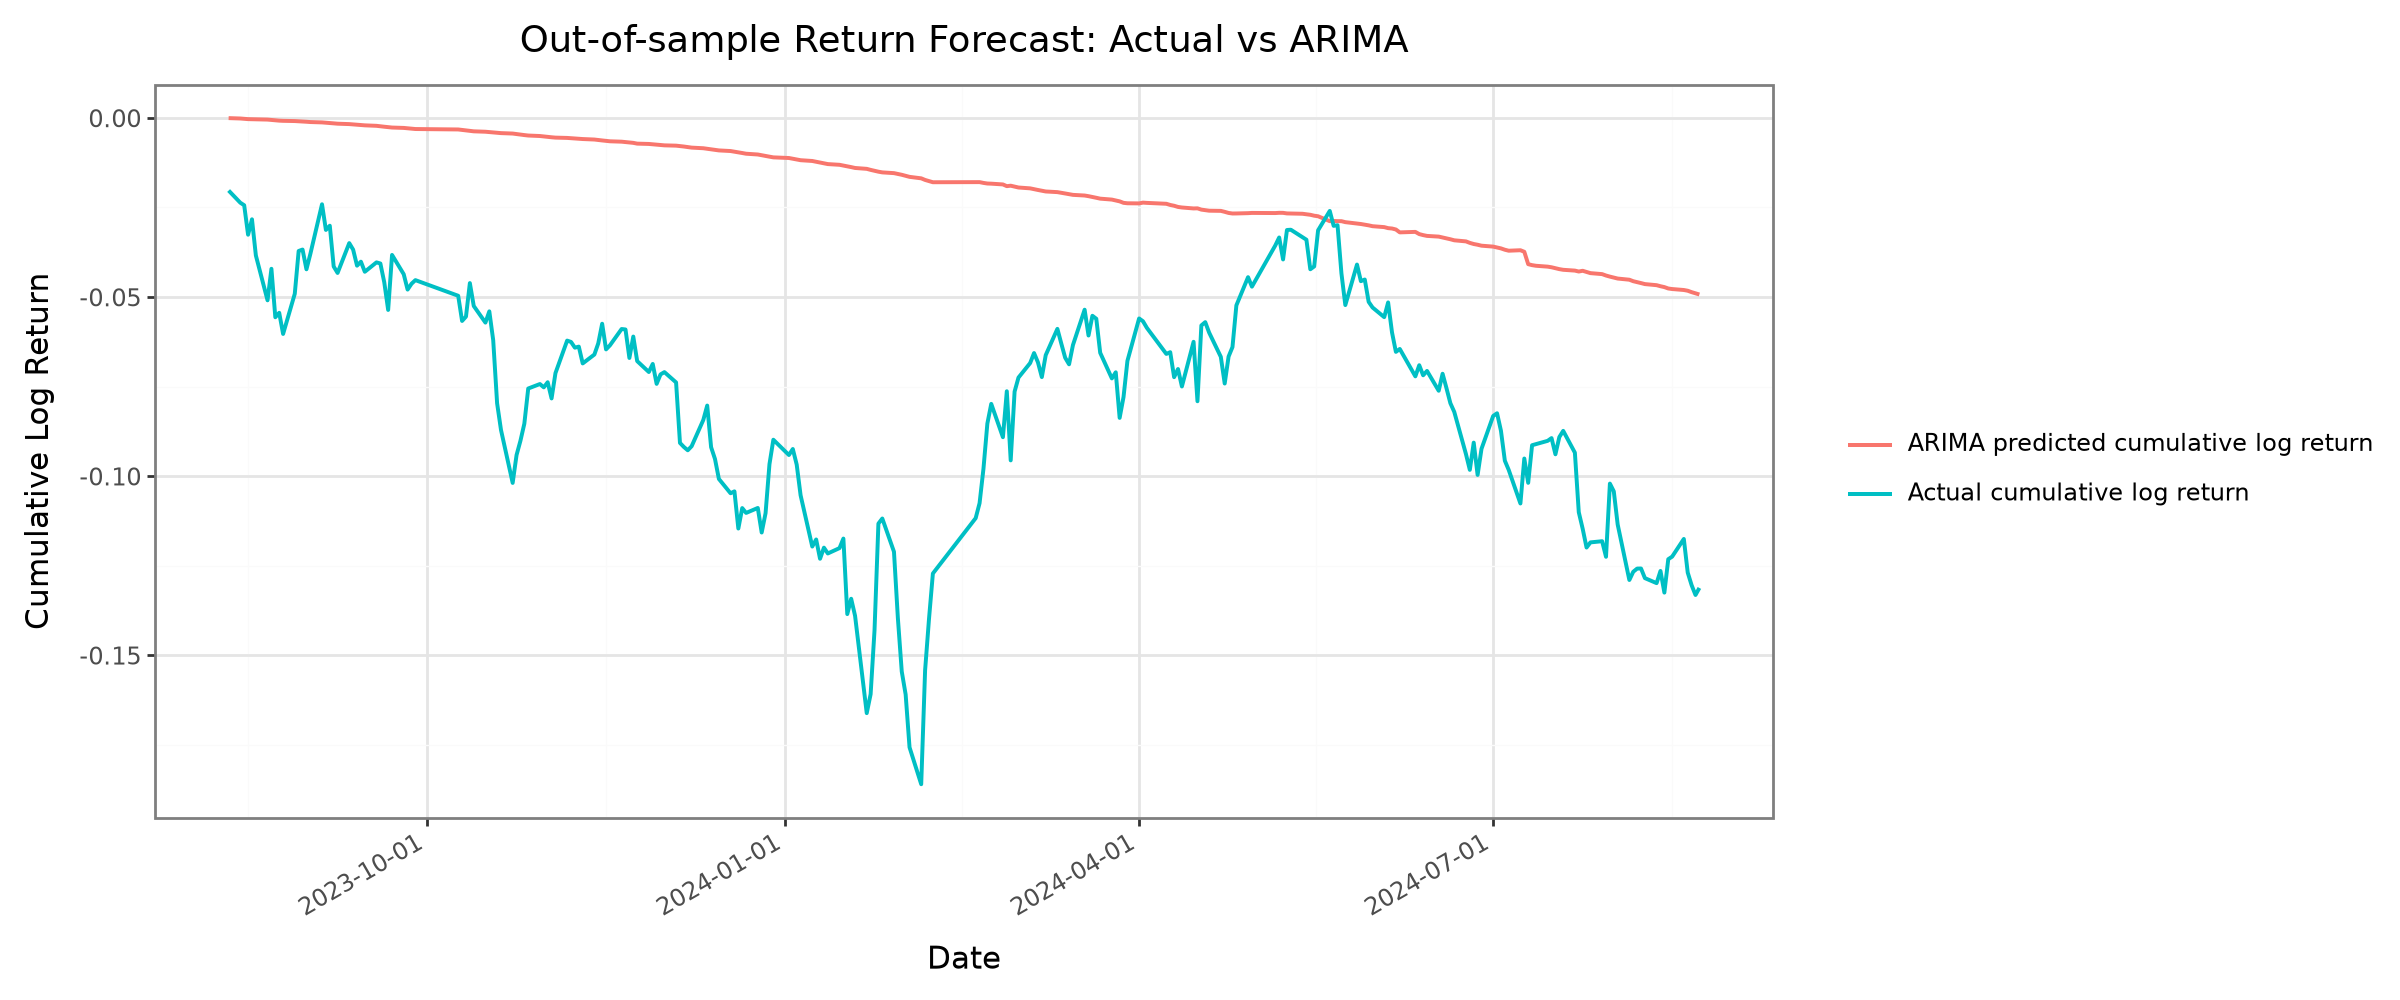

In [275]:
return_forecast_plot = pd.DataFrame({
    "Actual cumulative log return": forecast_df["actual_return"].cumsum(),
    "ARIMA predicted cumulative log return": forecast_df["arima"].cumsum(),
})
plot_line_comparison(
    return_forecast_plot,
    "Out-of-sample Return Forecast: Actual vs ARIMA",
    y_label="Cumulative Log Return",
)
        


### 简单择时回测

当预测收益率为正时持有指数，否则空仓。这里加入单边 5bp 的交易成本，用来避免过于乐观的策略结果。


In [276]:
def performance_stats(returns, periods_per_year=252):
    returns = returns.dropna()
    equity = (1 + returns).cumprod()
    ann_ret = equity.iloc[-1] ** (periods_per_year / len(returns)) - 1
    ann_vol = returns.std() * np.sqrt(periods_per_year)
    sharpe = ann_ret / ann_vol if ann_vol != 0 else np.nan
    max_dd = (equity / equity.cummax() - 1).min()
    win_rate = (returns > 0).mean()
    return pd.Series({
        "AnnualReturn": ann_ret,
        "AnnualVol": ann_vol,
        "Sharpe": sharpe,
        "MaxDrawdown": max_dd,
        "WinRate": win_rate,
        "TotalReturn": equity.iloc[-1] - 1,
    })

transaction_cost = 0.0005
backtest = forecast_df.copy()
backtest["signal"] = (backtest["arima"] > 0).astype(int)
backtest["signal_change"] = backtest["signal"].diff().abs().fillna(backtest["signal"])
backtest["strategy_return"] = backtest["signal"] * backtest["actual_return"] - transaction_cost * backtest["signal_change"]
backtest["buy_hold_return"] = backtest["actual_return"]

performance = pd.DataFrame({
    "ARIMA timing": performance_stats(backtest["strategy_return"]),
    "Buy and hold": performance_stats(backtest["buy_hold_return"]),
}).T

performance.to_csv(OUTPUT_DIR / "stock_prediction_backtest_performance.csv", encoding="utf-8-sig")
performance


,AnnualReturn,AnnualVol,Sharpe,MaxDrawdown,WinRate,TotalReturn
ARIMA timing,-0.037831,0.036316,-1.041716,-0.052009,0.015873,-0.037831
Buy and hold,-0.130633,0.132573,-0.985359,-0.156224,0.488095,-0.130633


**小结：** 回测结果需要同时看收益、波动、Sharpe 和最大回撤。若策略扣除交易成本后不能稳定优于买入持有，则更适合作为时间序列建模练习，而不是成熟交易策略。


### 回测净值曲线


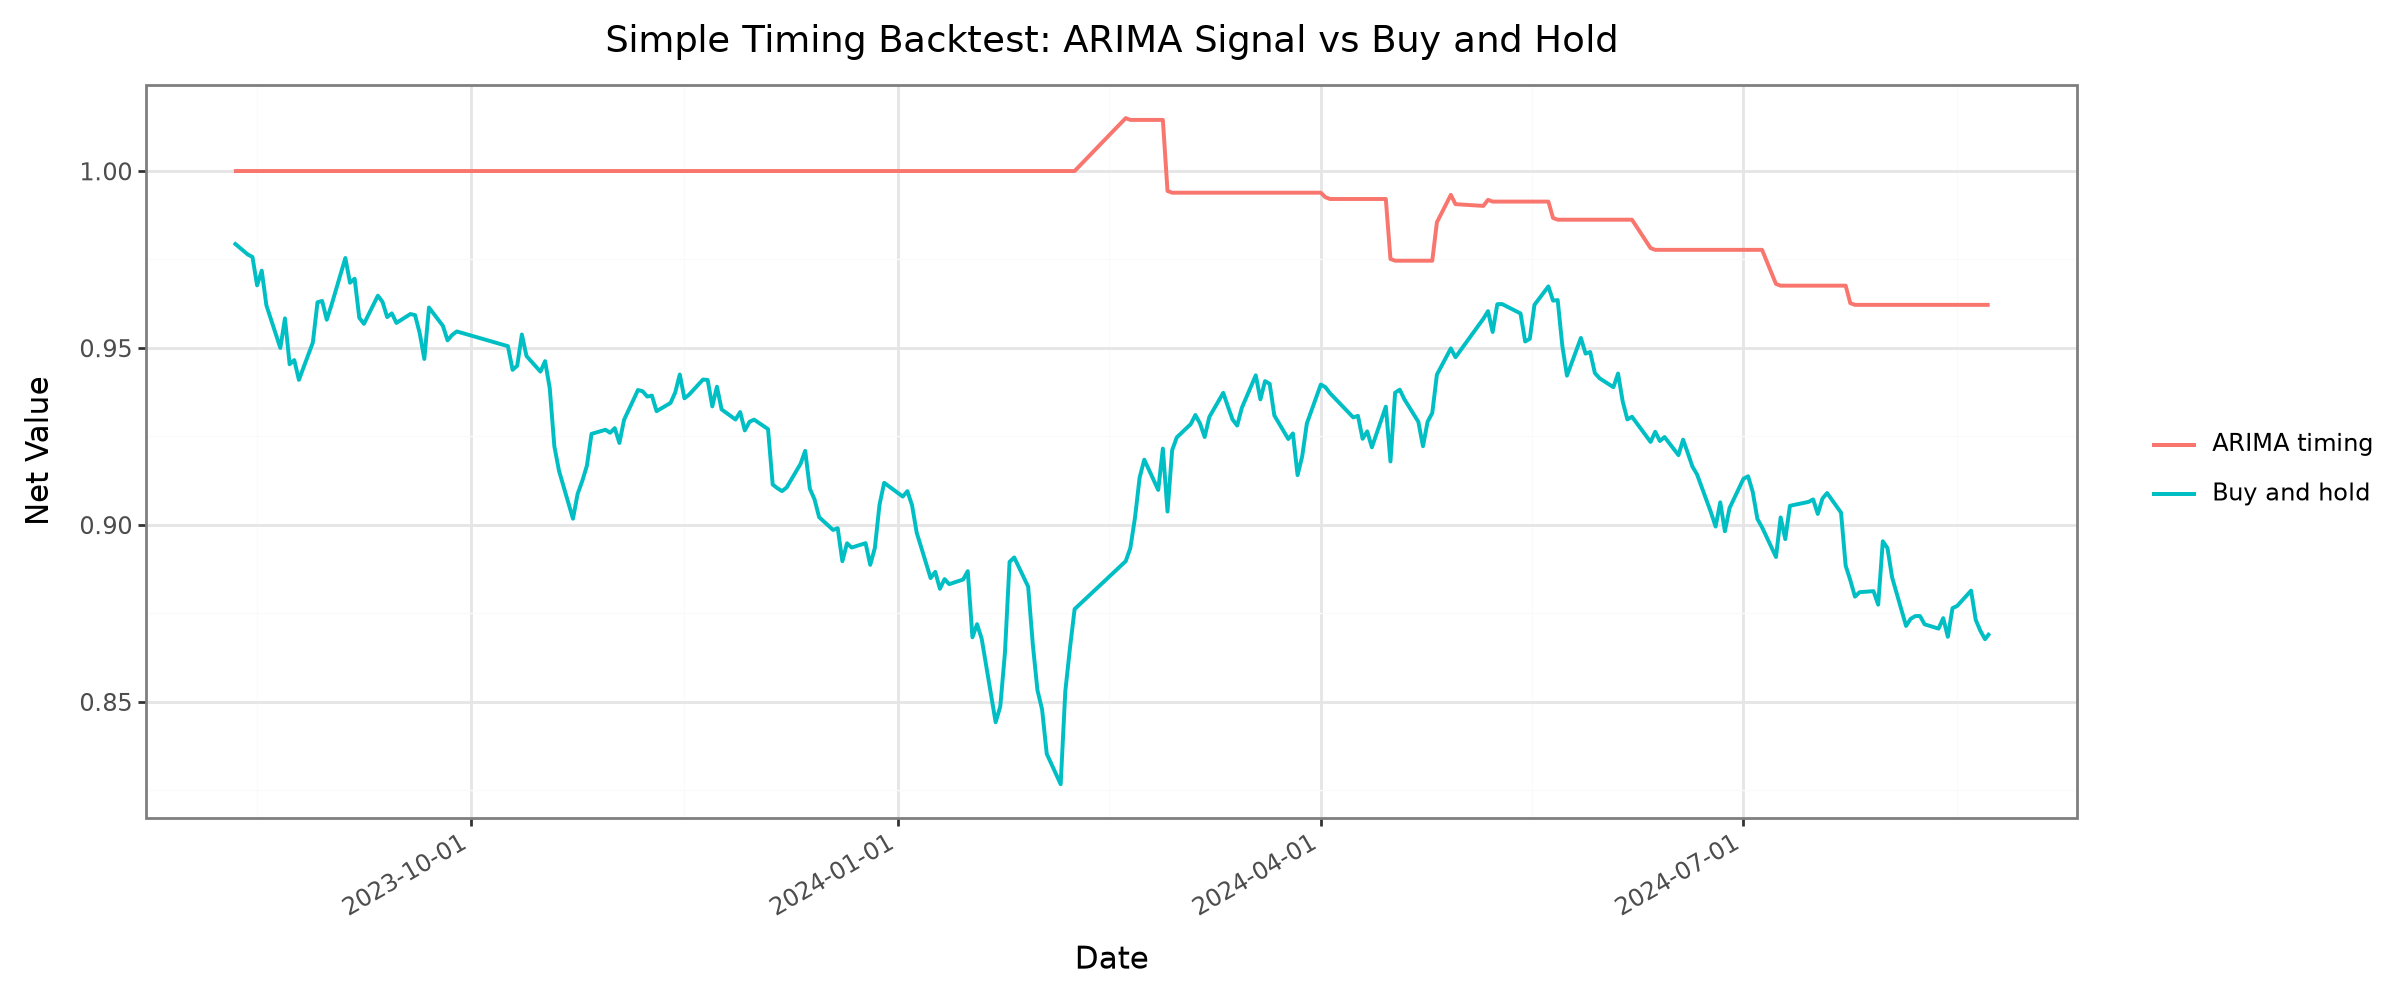

In [277]:
equity = pd.DataFrame({
    "ARIMA timing": (1 + backtest["strategy_return"]).cumprod(),
    "Buy and hold": (1 + backtest["buy_hold_return"]).cumprod(),
})

plot_line_comparison(
    equity,
    "Simple Timing Backtest: ARIMA Signal vs Buy and Hold",
    y_label="Net Value",
)
        


## 结论

本文以上证指数价格序列为研究对象，按照时间序列分析的一般流程，依次完成了数据预处理、平稳性观察、对数变换、一阶差分、ACF/PACF 分析、ARIMA/SARIMA 模型选择、残差检验和样本外预测。原始价格序列具有明显趋势，直接建模并不合适，因此需要通过对数和差分处理改善序列的平稳性。

从模型结果看，ARIMA/SARIMA 可以捕捉指数序列中的一部分短期相关结构，样本外预测也能给出较为平滑的价格走势和预测区间。但金融价格本身噪声较强，价格预测误差仍然存在，因此模型结果更适合作为时间序列建模练习，而不能直接理解为稳定可靠的交易信号。

在收益率预测和简单择时回测部分可以看到，相比价格水平，收益率的预测难度更高。简单 ARIMA 信号并不一定能稳定优于基准策略。总体而言，本 notebook 的重点是展示完整的时间序列建模、诊断、预测和基础评价流程，而不是构建成熟的量化交易策略。
